[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/06_kkt_conditions_and_duality/first_principles.ipynb)

# Module 06 — KKT Conditions and Lagrangian Duality

## 1. Why This Module Exists

Equality constraints pin a decision **onto** a surface, and the Lagrange multiplier rule of `optimization/05` handles them completely. Inequality constraints do something different: they fence off a *region*. A fence matters only if you are leaning on it, and it can only push you back — never pull you toward itself. That single asymmetry is the whole difficulty, and the Karush–Kuhn–Tucker (KKT) conditions are its resolution.

The resolution has two moving parts. A **sign condition** $\mu_i \ge 0$ records that a fence pushes outward only, and a **complementarity condition** $\mu_i g_i(\mathbf{x}^*) = 0$ records that a fence you are not touching exerts nothing. Together with stationarity and feasibility they form a finite algebraic system that a constrained optimum must satisfy — provided the constraint description is regular enough for the fences to have well-defined normals.

The same structure arrives a second time from a completely different direction. Replace each hard constraint by a *price* per unit of violation and minimize the resulting unconstrained bill: every price vector yields a certified lower bound on the true optimum, the best such bound is the **dual problem**, and the dual is concave no matter how badly behaved the primal is. When the two values meet, the optimal prices are exactly the KKT multipliers. Duality is therefore not a parallel theory but the same theory seen from the buyer's side.

This is the machinery behind the support-vector-machine dual and the kernel trick, water-filling in channel-capacity allocation, shadow prices in linear programming, the contact forces a physics engine solves for at every timestep, and the optimality certificate that every convex solver prints when it stops. Module `optimization/07` builds LP, QP, SOCP and SDP directly on top of the dual pair established here.

## 2. Intuition

### 2.1 Walls Can Push but Never Pull

Stand at a candidate optimum $\mathbf{x}^*$ and sort the inequality constraints into two classes:

- **Inactive** ($g_i(\mathbf{x}^*) \lt 0$): you are strictly inside this fence. Small motions cannot violate it, so locally it might as well not exist. Its price should be $\mu_i = 0$.
- **Active** ($g_i(\mathbf{x}^*) = 0$): you are touching this fence. It restricts motion, but only *one-sidedly* — you may slide along it or step away into the interior, just not through it.

The one-sidedness produces a sign condition absent from the equality theory. At a minimum the steepest-descent direction $-\nabla f$ must be blocked by the fences, i.e. it must point into the forbidden side, which means it is a **nonnegative** combination of the outward normals $\nabla g_i$ of the active fences:

$$
\nabla f(\mathbf{x}^*) + \sum_{i \in \mathcal{A}(\mathbf{x}^*)} \mu_i \nabla g_i(\mathbf{x}^*) = \mathbf{0}, \qquad \mu_i \ge 0.
$$

A wall exerts force only along its outward normal, and only pushing. A negative $\mu_i$ would be a wall pulling you toward it. Packaging "inactive implies zero price" as the single equation $\mu_i g_i(\mathbf{x}^*) = 0$ gives **complementary slackness**, and the full package is the KKT system of Definition 3.3.

### 2.2 Duality as Principled Bargaining

There is a second, independent road to the same equations: instead of exploring the feasible region, pay someone to enforce the constraints for you. Replace each hard constraint $g_i(\mathbf{x}) \le 0$ by a linear fine of $\mu_i \ge 0$ per unit of violation, so the bill is the Lagrangian

$$
\mathcal{L}(\mathbf{x}, \boldsymbol{\mu}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \sum_{i=1}^m \mu_i g_i(\mathbf{x}) + \sum_{j=1}^p \lambda_j h_j(\mathbf{x}),
$$

now minimized *freely* over all $\mathbf{x} \in \mathbb{R}^n$. Two observations create the theory.

**Any price sheet gives a lower bound.** On the feasible set the fines are nonpositive, so the relaxed cost never exceeds the true cost there, and minimizing freely goes lower still. Every admissible price vector therefore produces a certified lower bound on the unknown optimum.

**The enforcer maximizes.** The best such bound is the dual problem $d^* = \sup_{\boldsymbol{\mu} \ge \mathbf{0}, \boldsymbol{\lambda}} g(\boldsymbol{\mu}, \boldsymbol{\lambda})$, and that problem is always concave, no matter how badly behaved $f$ and $g_i$ are. The gap $p^* - d^* \ge 0$ measures what linear pricing cannot see. For convex problems with a strictly feasible point nothing is lost.

### 2.3 The Saddle-Point Game

Both roads meet in a two-player zero-sum game. The designer picks $\mathbf{x}$ to minimize $\mathcal{L}$; the enforcer picks prices to maximize it.

If the designer commits first, the enforcer punishes any violation with unbounded prices, so the designer must play feasibly:

$$
\sup_{\boldsymbol{\mu} \ge \mathbf{0}, \boldsymbol{\lambda}} \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}, \boldsymbol{\lambda}) =
\begin{cases}
f(\mathbf{x}), & \mathbf{x} \text{ feasible}, \\
+\infty, & \text{otherwise},
\end{cases}
$$

so $\inf_{\mathbf{x}} \sup \mathcal{L} = p^*$ is the primal problem in disguise. If the enforcer commits first, the designer minimizes freely and $\sup \inf \mathcal{L} = d^*$. Weak duality is then the universal fact that moving second never hurts, and strong duality says the game has a **saddle point** at which the order of play is irrelevant.

The preamble below fixes plotting defaults and the single random generator used everywhere in this notebook, and defines the small active-set QP solver reused by every later cell.

In [1]:
import itertools

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps
print(f"machine epsilon = {EPS:.4e}")


def solve_qp_active_set(Q, c, A, b, tol=1e-9):
    """Minimize 0.5 x'Qx + c'x subject to Ax <= b by enumerating active sets.

    Returns (value, x, mu) for the best KKT point found: for a convex QP
    (Q positive definite) that point is the global minimizer by Theorem 4.5.
    """
    n, m = Q.shape[0], A.shape[0]
    best = None
    for mask in itertools.product((0, 1), repeat=m):
        idx = [i for i in range(m) if mask[i]]
        k = len(idx)
        K = np.zeros((n + k, n + k))
        K[:n, :n] = Q
        if k:
            K[:n, n:] = A[idx].T
            K[n:, :n] = A[idx]
        rhs = np.concatenate([-c, b[idx]])
        try:
            sol = np.linalg.solve(K, rhs)
        except np.linalg.LinAlgError:
            continue
        x, mu = sol[:n], np.zeros(m)
        mu[idx] = sol[n:]
        if np.all(A @ x - b <= tol) and np.all(mu >= -tol):
            value = 0.5 * x @ Q @ x + c @ x
            if best is None or value < best[0]:
                best = (value, x, mu)
    return best


print("solve_qp_active_set ready")

machine epsilon = 2.2204e-16
solve_qp_active_set ready


The printed machine epsilon is the yardstick every residual in this notebook is measured against: a quantity of order $10^{-16}$ is zero in floating point, while anything of order $10^{-2}$ is a genuine mathematical discrepancy.

The figure below draws the geometry of Section 2.1 on the triangle $\{x_1, x_2 \ge 0,\ x_1 + x_2 \le 1\}$ with objective $f(\mathbf{x}) = \lVert \mathbf{x} - (1.5, 0.2) \rVert^2$. The minimizer sits at the corner $(1, 0)$, where two fences are active, so $-\nabla f$ must lie inside the cone they span.

grad f at the corner: [-1.  -0.4]
multipliers (mu_1, mu_3): [1.  0.6]  both nonnegative: True


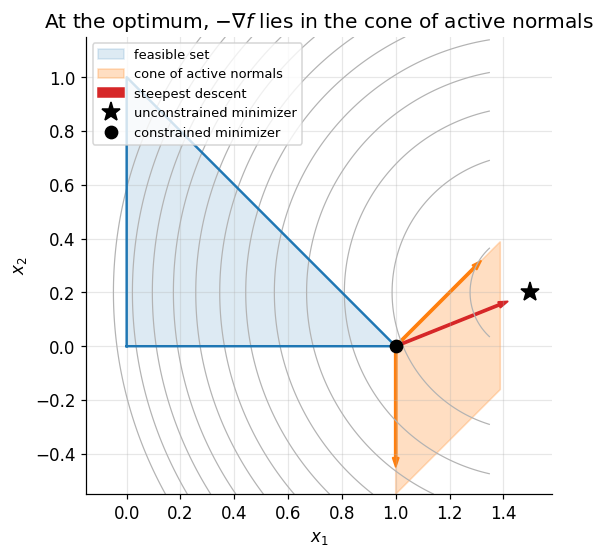

In [2]:
target = np.array([1.5, 0.2])
x_corner = np.array([1.0, 0.0])
grad_f = 2.0 * (x_corner - target)          # gradient of ||x - target||^2
n1 = np.array([1.0, 1.0])                    # outward normal of x1 + x2 <= 1
n3 = np.array([0.0, -1.0])                   # outward normal of -x2 <= 0
mu = np.linalg.solve(np.column_stack([n1, n3]), -grad_f)
print("grad f at the corner:", grad_f)
print("multipliers (mu_1, mu_3):", mu, " both nonnegative:", bool(np.all(mu >= 0)))

gx = np.linspace(-0.15, 1.35, 400)
gy = np.linspace(-0.55, 1.15, 400)
GX, GY = np.meshgrid(gx, gy)
FF = (GX - target[0]) ** 2 + (GY - target[1]) ** 2

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.contour(GX, GY, FF, levels=np.linspace(0.05, 2.4, 12), colors="0.7", linewidths=0.8)
ax.fill([0, 1, 0], [0, 0, 1], color="tab:blue", alpha=0.15, label="feasible set")
ax.plot([0, 1, 0, 0], [0, 0, 1, 0], color="tab:blue", lw=1.6)
cone = np.array([x_corner, x_corner + 0.55 * n1 / np.linalg.norm(n1),
                 x_corner + 0.55 * (n1 / np.linalg.norm(n1) + n3), x_corner + 0.55 * n3])
ax.fill(cone[:, 0], cone[:, 1], color="tab:orange", alpha=0.25,
        label="cone of active normals")
ax.arrow(*x_corner, *(0.45 * n1 / np.linalg.norm(n1)), width=0.008,
         color="tab:orange", length_includes_head=True)
ax.arrow(*x_corner, *(0.45 * n3), width=0.008, color="tab:orange",
         length_includes_head=True)
ax.arrow(*x_corner, *(0.45 * (-grad_f) / np.linalg.norm(grad_f)), width=0.008,
         color="tab:red", length_includes_head=True, label="steepest descent")
ax.plot(*target, "k*", ms=13, label="unconstrained minimizer")
ax.plot(*x_corner, "ko", ms=8, label="constrained minimizer")
ax.set_aspect("equal")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("At the optimum, $-\\nabla f$ lies in the cone of active normals")
ax.legend(loc="upper left", fontsize=8.5)
plt.show()

Both multipliers are positive, so $-\nabla f$ sits strictly inside the orange cone: descent is blocked in every feasible direction. Move the target so that $-\nabla f$ leaves the cone and the corner stops being optimal — the cone membership *is* the optimality condition, and Lemma 4.1 will turn that geometric statement into algebra.

## 3. Definitions

### Definition 3.1 (Standard-form problem and active set)

Let $f, g_1, \dots, g_m, h_1, \dots, h_p : \mathbb{R}^n \to \mathbb{R}$ be continuously differentiable. The **primal problem** is

$$
p^* = \min_{\mathbf{x} \in \mathbb{R}^n} f(\mathbf{x}) \quad \text{subject to} \quad g_i(\mathbf{x}) \le 0 \; (i = 1, \dots, m), \qquad h_j(\mathbf{x}) = 0 \; (j = 1, \dots, p).
$$

The **active set** at a feasible point $\mathbf{x}$ is $\mathcal{A}(\mathbf{x}) = \{i : g_i(\mathbf{x}) = 0\}$. Inequalities with $g_i(\mathbf{x}) \lt 0$ are **inactive** at $\mathbf{x}$.

### Definition 3.2 (Lagrangian)

With multipliers $\boldsymbol{\mu} \in \mathbb{R}^m$ for the inequalities and $\boldsymbol{\lambda} \in \mathbb{R}^p$ for the equalities,

$$
\mathcal{L}(\mathbf{x}, \boldsymbol{\mu}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \sum_{i=1}^m \mu_i g_i(\mathbf{x}) + \sum_{j=1}^p \lambda_j h_j(\mathbf{x}).
$$

### Definition 3.3 (KKT conditions)

A point $\mathbf{x}^*$ with multipliers $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ satisfies the **Karush–Kuhn–Tucker conditions** if all four hold:

1. **Stationarity:**

$$
\nabla f(\mathbf{x}^*) + \sum_{i=1}^m \mu_i^* \nabla g_i(\mathbf{x}^*) + \sum_{j=1}^p \lambda_j^* \nabla h_j(\mathbf{x}^*) = \mathbf{0}
$$

2. **Primal feasibility:** $g_i(\mathbf{x}^*) \le 0$ for all $i$ and $h_j(\mathbf{x}^*) = 0$ for all $j$.
3. **Dual feasibility:** $\mu_i^* \ge 0$ for all $i$.
4. **Complementary slackness:** $\mu_i^* g_i(\mathbf{x}^*) = 0$ for all $i$.

Such a triple is a **KKT point**. **Strict complementarity** holds at a KKT point when $\mu_i^* \gt 0$ for every $i \in \mathcal{A}(\mathbf{x}^*)$, i.e. no active constraint carries a zero price; the pair $(g_i, \mu_i)$ is then never simultaneously zero.

### Definition 3.4 (Constraint qualifications)

Let $\mathbf{x}$ be feasible for the problem of Definition 3.1.

- **LICQ** holds at $\mathbf{x}$ if the vectors $\{\nabla g_i(\mathbf{x}) : i \in \mathcal{A}(\mathbf{x})\} \cup \{\nabla h_j(\mathbf{x}) : j = 1, \dots, p\}$ are linearly independent.
- **MFCQ** holds at $\mathbf{x}$ if $\{\nabla h_j(\mathbf{x})\}_{j=1}^p$ are linearly independent and there is $\mathbf{d} \in \mathbb{R}^n$ with $\nabla g_i(\mathbf{x})^T \mathbf{d} \lt 0$ for every $i \in \mathcal{A}(\mathbf{x})$ and $\nabla h_j(\mathbf{x})^T \mathbf{d} = 0$ for every $j$.
- **Slater's condition** applies to a convex problem ($f, g_i$ convex, $\mathbf{h}(\mathbf{x}) = A\mathbf{x} - \mathbf{b}$ affine) and asks for a point $\mathbf{x}_0$ with $g_i(\mathbf{x}_0) \lt 0$ for all $i$ and $A\mathbf{x}_0 = \mathbf{b}$.

LICQ implies MFCQ. Slater is a *global* hypothesis about the feasible region rather than a condition at one point; affine inequality constraints need only be satisfied, not strictly satisfied.

### Definition 3.5 (Linearized feasible directions and the tangent cone)

At a feasible $\mathbf{x}$, the **cone of linearized feasible directions** is

$$
\mathcal{F}(\mathbf{x}) = \{\mathbf{d} \in \mathbb{R}^n : \nabla g_i(\mathbf{x})^T \mathbf{d} \le 0 \ (i \in \mathcal{A}(\mathbf{x})), \ \nabla h_j(\mathbf{x})^T \mathbf{d} = 0 \ (j = 1, \dots, p)\}.
$$

The **tangent cone** $T(\mathbf{x})$ is the set of $\mathbf{d}$ for which there exist feasible points $\mathbf{x}_k \to \mathbf{x}$ and scalars $t_k \downarrow 0$ with $(\mathbf{x}_k - \mathbf{x})/t_k \to \mathbf{d}$. Always $T(\mathbf{x}) \subseteq \mathcal{F}(\mathbf{x})$; the reverse inclusion is what a constraint qualification buys.

### Definition 3.6 (Critical cone)

At a KKT point $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ the **critical cone** is

$$
\mathcal{C}(\mathbf{x}^*, \boldsymbol{\mu}^*) = \{\mathbf{d} \in \mathcal{F}(\mathbf{x}^*) : \nabla g_i(\mathbf{x}^*)^T \mathbf{d} = 0 \ \text{ for every } i \in \mathcal{A}(\mathbf{x}^*) \text{ with } \mu_i^* \gt 0\}.
$$

These are the directions along which the first-order information is exactly neutral: $\nabla f(\mathbf{x}^*)^T \mathbf{d} = 0$ for every $\mathbf{d} \in \mathcal{C}(\mathbf{x}^*, \boldsymbol{\mu}^*)$, so only curvature can decide them.

### Definition 3.7 (Dual function and dual problem)

The **Lagrange dual function** is

$$
g(\boldsymbol{\mu}, \boldsymbol{\lambda}) = \inf_{\mathbf{x} \in \mathbb{R}^n} \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}, \boldsymbol{\lambda}) \in [-\infty, +\infty),
$$

with effective domain $\operatorname{dom} g = \{(\boldsymbol{\mu}, \boldsymbol{\lambda}) : g(\boldsymbol{\mu}, \boldsymbol{\lambda}) \gt -\infty\}$. The **dual problem** is

$$
d^* = \sup_{\boldsymbol{\mu} \ge \mathbf{0}, \; \boldsymbol{\lambda} \in \mathbb{R}^p} g(\boldsymbol{\mu}, \boldsymbol{\lambda}),
$$

and $p^* - d^*$ is the **duality gap**.

### Definition 3.8 (Perturbed problem and value function)

For $\mathbf{u} \in \mathbb{R}^m$ and $\mathbf{v} \in \mathbb{R}^p$ the **perturbed problem** replaces the constraints by $g_i(\mathbf{x}) \le u_i$ and $h_j(\mathbf{x}) = v_j$; its optimal value $p^*(\mathbf{u}, \mathbf{v})$ is the **value function**, with $p^*(\mathbf{0}, \mathbf{0}) = p^*$.

### Definition 3.9 (LP dual pair and the hard-margin SVM)

For $\mathbf{c} \in \mathbb{R}^n$, $A \in \mathbb{R}^{m \times n}$, $\mathbf{b} \in \mathbb{R}^m$ the symmetric-form linear programming pair is:

| Primal (variables $\mathbf{x}$) | Dual (variables $\mathbf{y}$) |
|---|---|
| minimize $\mathbf{c}^T \mathbf{x}$ | maximize $\mathbf{b}^T \mathbf{y}$ |
| subject to $A\mathbf{x} \ge \mathbf{b}$ | subject to $A^T \mathbf{y} \le \mathbf{c}$ |
| and $\mathbf{x} \ge \mathbf{0}$ | and $\mathbf{y} \ge \mathbf{0}$ |

Each primal constraint row spawns a dual variable, and each primal variable spawns a dual constraint. Given separable data $(\mathbf{x}_i, y_i)$ with $y_i \in \{-1, +1\}$, the **hard-margin SVM** primal is

$$
\min_{\mathbf{w}, b} \; \tfrac{1}{2} \lVert \mathbf{w} \rVert^2 \quad \text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \ge 1, \quad i = 1, \dots, N.
$$

## 4. Main Results

### Lemma 4.1 (Farkas' lemma)

Let $\mathbf{a}_1, \dots, \mathbf{a}_k, \mathbf{c} \in \mathbb{R}^n$. Exactly one of the following holds:

1. $\mathbf{c} = \sum_{i=1}^k \mu_i \mathbf{a}_i$ for some $\mu_i \ge 0$;
2. there exists $\mathbf{d} \in \mathbb{R}^n$ with $\mathbf{a}_i^T \mathbf{d} \le 0$ for every $i$ and $\mathbf{c}^T \mathbf{d} \gt 0$.

*Hypotheses.* Only finiteness of the list is needed: it makes the cone $\{\sum_i \mu_i \mathbf{a}_i : \mu_i \ge 0\}$ closed, which is what lets a separating hyperplane be produced in Proof 5.1. For infinitely many generators the cone can fail to be closed and the dichotomy fails.

$$
\boxed{\text{either } \mathbf{c} \in \operatorname{cone}\{\mathbf{a}_i\} \text{ or a single direction } \mathbf{d} \text{ certifies that it is not — never both}}
$$

**Interpretation.** A membership question about a cone always has a one-vector answer: a nonnegative recipe if $\mathbf{c}$ is inside, a separating direction if it is not. The consequence used throughout this module is that "no descent direction is feasible" — a statement quantified over all $\mathbf{d}$ — can always be replaced by the existence of finitely many nonnegative multipliers.

### Corollary 4.2 (Gordan's theorem)

Let $\mathbf{a}_1, \dots, \mathbf{a}_k \in \mathbb{R}^n$. Exactly one of the following holds:

1. there exists $\mathbf{d}$ with $\mathbf{a}_i^T \mathbf{d} \lt 0$ for every $i$;
2. there exist $y_i \ge 0$, not all zero, with $\sum_{i=1}^k y_i \mathbf{a}_i = \mathbf{0}$.

*Hypotheses.* Same finiteness as Lemma 4.1, from which Proof 5.2 derives it. This is the theorem of the alternative behind MFCQ: alternative (1) with $\mathbf{a}_i = \nabla g_i(\mathbf{x})$ is exactly the MFCQ direction, and its failure produces a nonzero nonnegative combination of active gradients that vanishes, i.e. a Fritz John multiplier with zero objective weight.

### Lemma 4.3 (Under LICQ the linearized cone is the tangent cone)

If $\mathbf{x}^*$ is feasible and LICQ holds at $\mathbf{x}^*$, then $T(\mathbf{x}^*) = \mathcal{F}(\mathbf{x}^*)$. Concretely, for every $\mathbf{d} \in \mathcal{F}(\mathbf{x}^*)$ there is a $C^1$ curve $\mathbf{z}(t)$, defined for $t$ in a neighbourhood of $0$, with $\mathbf{z}(0) = \mathbf{x}^*$, $\mathbf{z}'(0) = \mathbf{d}$, and $\mathbf{z}(t)$ feasible for all sufficiently small $t \ge 0$.

*Hypotheses.* Linear independence of the active gradients is what makes the Jacobian in Proof 5.3 invertible, so the implicit function theorem applies; without it a linearized direction can point out of the feasible set entirely (Example 6.3). Continuous differentiability of the constraints is needed for the implicit function theorem itself.

### Theorem 4.4 (KKT necessity under LICQ)

Let $\mathbf{x}^*$ be a **local minimizer** of the problem of Definition 3.1 at which **LICQ holds**. Then there exist multipliers $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ such that $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ satisfies the KKT conditions of Definition 3.3, and those multipliers are **unique**.

*Hypotheses.* Local minimality is what forbids a feasible descent direction, which is the input to Lemma 4.1; without it a stationary saddle need carry no nonnegative multipliers. LICQ is what upgrades "no *linearized* feasible descent direction" to "no *actual* feasible descent direction" through Lemma 4.3, and it is also what forces uniqueness — the stationarity equation then has a unique solution in the multipliers because the gradients involved are independent. Continuous differentiability is needed for the gradients to exist and for the curve construction.

No convexity is assumed anywhere in Theorem 4.4, and no strong duality: this is a purely local, purely first-order statement, and Proof 5.4 proves it from Lemma 4.1 and Lemma 4.3 alone.

$$
\boxed{\text{local minimizer} + \text{LICQ} \ \Longrightarrow \ \exists ! \, (\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \text{ with } (\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \text{ a KKT point}}
$$

**Interpretation.** Optimality, a statement about infinitely many nearby points, is compressed into finitely many equations and sign conditions. The consequence is algorithmic: solving a constrained optimization problem can be replaced by solving the KKT system, and any candidate solution can be *certified* by exhibiting multipliers rather than by searching its neighbourhood.

### Theorem 4.5 (KKT sufficiency for convex problems)

Suppose $f$ and every $g_i$ are **convex**, every $h_j$ is **affine**, all are differentiable, and $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ satisfies the KKT conditions. Then $\mathbf{x}^*$ is a **global** minimizer, $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ is dual optimal, and $p^* = d^*$.

*Hypotheses.* Convexity of $f$ and of each $g_i$ (with $\mu_i^* \ge 0$) is what makes $\mathcal{L}(\cdot, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ convex, so that stationarity gives a *global* minimum of the Lagrangian rather than a local one; affineness of $h_j$ is needed because $\lambda_j^*$ may be negative and only an affine $h_j$ keeps $\lambda_j^* h_j$ convex for either sign. No constraint qualification appears: qualifications are needed for necessity, never for sufficiency.

### Theorem 4.6 (Weak duality)

For **every** problem of the form in Definition 3.1 — convex or not, differentiable or not — and every $\boldsymbol{\mu} \ge \mathbf{0}$, $\boldsymbol{\lambda} \in \mathbb{R}^p$,

$$
g(\boldsymbol{\mu}, \boldsymbol{\lambda}) \le p^*, \qquad \text{hence} \qquad d^* \le p^*.
$$

*Hypotheses.* Only $\boldsymbol{\mu} \ge \mathbf{0}$ is used, and it is essential: with a negative $\mu_i$ the term $\mu_i g_i(\tilde{\mathbf{x}})$ can be positive at a feasible $\tilde{\mathbf{x}}$ and the bound collapses.

### Theorem 4.7 (Concavity of the dual)

For every problem of the form in Definition 3.1, the dual function $g$ is concave on $\mathbb{R}^m \times \mathbb{R}^p$, and $\operatorname{dom} g$ is convex. The dual problem is therefore always a convex optimization problem.

*Hypotheses.* None beyond the Lagrangian being affine in $(\boldsymbol{\mu}, \boldsymbol{\lambda})$ for each fixed $\mathbf{x}$, which holds by construction. This is why a nonconvex primal still has a tractable dual relaxation.

### Theorem 4.8 (Strong duality under Slater)

Suppose the problem is **convex** ($f, g_i$ convex, $\mathbf{h}$ affine), **Slater's condition holds**, and $p^*$ is **finite**. Then $d^* = p^*$ and the dual optimum is **attained** at some $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ with $\boldsymbol{\mu}^* \ge \mathbf{0}$.

*Hypotheses.* Convexity makes the outcome set $\mathcal{A}$ of Proof 5.7 convex, which is what admits a supporting hyperplane. Slater's strictly feasible point is what forces that hyperplane to be non-vertical, i.e. $\mu_0 \gt 0$; without it the gap can be strictly positive even for a convex problem (Section 7, counterexample cell). Finiteness of $p^*$ is needed because there is no hyperplane to support at $-\infty$.

### Theorem 4.9 (Saddle-point characterization)

Let $\boldsymbol{\mu}^* \ge \mathbf{0}$. The triple $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ satisfies

$$
\mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}, \boldsymbol{\lambda}) \le \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \le \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \qquad \forall \, \mathbf{x}, \ \forall \, \boldsymbol{\mu} \ge \mathbf{0}, \ \boldsymbol{\lambda}
$$

**if and only if** $\mathbf{x}^*$ is primal optimal, $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ is dual optimal, and the duality gap is zero — in which case $\min_{\mathbf{x}} \max_{\boldsymbol{\mu} \ge \mathbf{0}} \mathcal{L} = \max_{\boldsymbol{\mu} \ge \mathbf{0}} \min_{\mathbf{x}} \mathcal{L}$.

*Hypotheses.* $\boldsymbol{\mu}^* \ge \mathbf{0}$ is needed for the left inequality to have content, since the enforcer's feasible set is the nonnegative orthant. No convexity or differentiability is used: the equivalence is an identity between two ways of writing the same pair of optimizations.

### Theorem 4.10 (Global sensitivity inequality)

Suppose strong duality holds for the unperturbed problem with dual optimum $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ attained. Then for **all** $\mathbf{u}, \mathbf{v}$,

$$
p^*(\mathbf{u}, \mathbf{v}) \ \ge \ p^*(\mathbf{0}, \mathbf{0}) - \boldsymbol{\mu}^{*T} \mathbf{u} - \boldsymbol{\lambda}^{*T} \mathbf{v}.
$$

If in addition $p^*$ is differentiable at $(\mathbf{0}, \mathbf{0})$ then $\partial p^* / \partial u_i = -\mu_i^*$ and $\partial p^* / \partial v_j = -\lambda_j^*$.

*Hypotheses.* Strong duality with attainment is what supplies the optimal price vector that the bound is written in; without attainment there is no $\boldsymbol{\mu}^*$ to use. Differentiability is needed only for the local statement — the inequality itself is global and holds even where $p^*$ has a kink.

$$
\boxed{p^*(\mathbf{u}, \mathbf{v}) \ge p^* - \boldsymbol{\mu}^{*T}\mathbf{u} - \boldsymbol{\lambda}^{*T}\mathbf{v}, \qquad -\frac{\partial p^*}{\partial u_i} = \mu_i^*}
$$

**Interpretation.** The optimal multipliers are the coefficients of a global affine *underestimator* of the value function: a large $\mu_i^*$ guarantees that tightening constraint $i$ hurts a lot, whereas a small $\mu_i^*$ only promises that loosening it helps little. The consequence in practice is that multipliers are shadow prices — the marginal worth of one more unit of resource $i$ — and this is exactly how locational marginal prices, water-filling levels and SVM support weights are read.

### Theorem 4.11 (Second-order necessary condition — cited, not proved here)

If $\mathbf{x}^*$ is a local minimizer, LICQ holds at $\mathbf{x}^*$, all functions are twice continuously differentiable, and $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ are the multipliers of Theorem 4.4, then

$$
\mathbf{d}^T \nabla^2_{\mathbf{x}\mathbf{x}} \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \, \mathbf{d} \ \ge \ 0 \qquad \text{for every } \mathbf{d} \in \mathcal{C}(\mathbf{x}^*, \boldsymbol{\mu}^*).
$$

Reference: Nocedal & Wright, *Numerical Optimization* (2nd ed.), Theorem 12.5, p. 332.

*Hypotheses.* LICQ is again what makes every critical direction realizable by a feasible curve; twice differentiability is what makes the quadratic form exist. The restriction to $\mathcal{C}$ is essential — outside the critical cone the first-order term already decides, so no curvature condition can be expected.

### Theorem 4.12 (Second-order sufficient condition — cited, not proved here)

If $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ is a KKT point, all functions are twice continuously differentiable, and

$$
\mathbf{d}^T \nabla^2_{\mathbf{x}\mathbf{x}} \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \, \mathbf{d} \ \gt \ 0 \qquad \text{for every nonzero } \mathbf{d} \in \mathcal{C}(\mathbf{x}^*, \boldsymbol{\mu}^*),
$$

then $\mathbf{x}^*$ is a **strict local minimizer**. Reference: Nocedal & Wright, *Numerical Optimization* (2nd ed.), Theorem 12.6, p. 333.

*Hypotheses.* No constraint qualification is required, exactly as in Theorem 4.5 — sufficiency never needs one. Strictness of the inequality is what rules out flat directions along which the objective could stay constant or decrease at higher order.

### Remark 4.13 (What MFCQ buys)

MFCQ is strictly weaker than LICQ and still forces the KKT multiplier set at $\mathbf{x}^*$ to be nonempty. The precise trade is this: MFCQ holds at a local minimizer $\mathbf{x}^*$ **if and only if** the set of KKT multipliers there is nonempty, convex, compact; LICQ holds if and only if that set is a single point. Reference: Nocedal & Wright, *Numerical Optimization* (2nd ed.), Section 12.6, p. 339 (Theorem 12.7 and the discussion of Gauvin's theorem).

## 5. Derivations and Proofs

### Proof 5.1 (of Lemma 4.1, Farkas' lemma)

**Step 1 (the two alternatives cannot both hold).** If $\mathbf{c} = \sum_i \mu_i \mathbf{a}_i$ with $\mu_i \ge 0$ and $\mathbf{d}$ satisfies $\mathbf{a}_i^T \mathbf{d} \le 0$ for all $i$, then $\mathbf{c}^T \mathbf{d} = \sum_i \mu_i (\mathbf{a}_i^T \mathbf{d}) \le 0$, contradicting $\mathbf{c}^T \mathbf{d} \gt 0$.

**Step 2 (the cone is closed and convex).** Let $K = \{\sum_i \mu_i \mathbf{a}_i : \mu_i \ge 0\}$. It is convex and a cone by inspection. It is also **closed**: a finitely generated cone is closed (Rockafellar, *Convex Analysis*, Theorem 19.1, p. 171; the proof reduces by Carathéodory's theorem for cones to a finite union of images of the closed simplex under linear maps of linearly independent generators). Closedness is the only place finiteness of the generating list is used.

**Step 3 (separate the point from the cone).** Suppose alternative (1) fails, i.e. $\mathbf{c} \notin K$. Let $\mathbf{q}$ be the Euclidean projection of $\mathbf{c}$ onto $K$, which exists and is unique because $K$ is nonempty, closed and convex, and set $\mathbf{d} = \mathbf{c} - \mathbf{q} \neq \mathbf{0}$. The projection characterization gives

$$
(\mathbf{c} - \mathbf{q})^T (\mathbf{k} - \mathbf{q}) \le 0 \qquad \text{for every } \mathbf{k} \in K,
$$

that is $\mathbf{d}^T \mathbf{k} \le \mathbf{d}^T \mathbf{q}$ for all $\mathbf{k} \in K$.

**Step 4 (the cone structure pins down the constant).** Taking $\mathbf{k} = 2\mathbf{q} \in K$ gives $2 \mathbf{d}^T \mathbf{q} \le \mathbf{d}^T \mathbf{q}$, so $\mathbf{d}^T \mathbf{q} \le 0$; taking $\mathbf{k} = \mathbf{0} \in K$ gives $0 \le \mathbf{d}^T \mathbf{q}$. Hence $\mathbf{d}^T \mathbf{q} = 0$ and therefore $\mathbf{d}^T \mathbf{k} \le 0$ for every $\mathbf{k} \in K$. In particular $\mathbf{a}_i^T \mathbf{d} \le 0$ for each $i$, since $\mathbf{a}_i \in K$.

**Step 5 (the separating direction certifies non-membership).** Finally

$$
\mathbf{c}^T \mathbf{d} = (\mathbf{q} + \mathbf{d})^T \mathbf{d} = \mathbf{q}^T \mathbf{d} + \lVert \mathbf{d} \rVert^2 = \lVert \mathbf{d} \rVert^2 \gt 0,
$$

so alternative (2) holds. Combining with Step 1, exactly one alternative holds. $\blacksquare$

### Proof 5.2 (of Corollary 4.2, Gordan's theorem)

**Step 1 (lift to $\mathbb{R}^{n+1}$).** Put $\tilde{\mathbf{a}}_i = (\mathbf{a}_i, 1) \in \mathbb{R}^{n+1}$ and $\tilde{\mathbf{c}} = (\mathbf{0}, 1) \in \mathbb{R}^{n+1}$, and apply Lemma 4.1 to this list.

**Step 2 (read alternative (2) of Lemma 4.1).** A vector $(\mathbf{d}, s) \in \mathbb{R}^{n+1}$ satisfies $\tilde{\mathbf{a}}_i^T (\mathbf{d}, s) \le 0$ for all $i$ and $\tilde{\mathbf{c}}^T(\mathbf{d}, s) \gt 0$ exactly when $\mathbf{a}_i^T \mathbf{d} \le -s$ for all $i$ and $s \gt 0$. Such a pair exists if and only if there is $\mathbf{d}$ with $\mathbf{a}_i^T \mathbf{d} \lt 0$ for all $i$ (take $s = -\max_i \mathbf{a}_i^T \mathbf{d} \gt 0$). This is Gordan's alternative (1).

**Step 3 (read alternative (1) of Lemma 4.1).** $\tilde{\mathbf{c}} = \sum_i y_i \tilde{\mathbf{a}}_i$ with $y_i \ge 0$ means $\sum_i y_i \mathbf{a}_i = \mathbf{0}$ and $\sum_i y_i = 1$. Any such $\mathbf{y}$ is nonnegative and nonzero; conversely a nonnegative nonzero $\mathbf{y}$ with $\sum_i y_i \mathbf{a}_i = \mathbf{0}$ can be scaled to sum to one. This is Gordan's alternative (2).

**Step 4 (conclude).** Lemma 4.1 says exactly one of its alternatives holds, so exactly one of Gordan's holds. $\blacksquare$

### Proof 5.3 (of Lemma 4.3)

**Step 1 (set up the active system).** Let $\mathcal{A} = \mathcal{A}(\mathbf{x}^*)$ and stack the active constraint functions into $\mathbf{c}(\mathbf{x}) = (g_i(\mathbf{x}))_{i \in \mathcal{A}}$ together with $\mathbf{h}(\mathbf{x})$, writing $C(\mathbf{x}) \in \mathbb{R}^{q \times n}$ for the Jacobian of that stack, $q = \lvert \mathcal{A} \rvert + p$. LICQ says $C(\mathbf{x}^*)$ has full row rank $q$, so $q \le n$. Choose $Z \in \mathbb{R}^{n \times (n-q)}$ whose columns form a basis of the null space of $C(\mathbf{x}^*)$.

**Step 2 (write a square system whose solution is the curve).** Fix $\mathbf{d} \in \mathcal{F}(\mathbf{x}^*)$ and define $R : \mathbb{R}^n \times \mathbb{R} \to \mathbb{R}^n$ by

$$
R(\mathbf{z}, t) = \begin{bmatrix} \mathbf{c}_{\text{act}}(\mathbf{z}) - t \, C(\mathbf{x}^*) \mathbf{d} \\ Z^T (\mathbf{z} - \mathbf{x}^* - t \mathbf{d}) \end{bmatrix},
$$

where $\mathbf{c}_{\text{act}}$ is the stacked active-constraint vector of Step 1. Then $R(\mathbf{x}^*, 0) = \mathbf{0}$ because $\mathbf{x}^*$ is feasible with those constraints active.

**Step 3 (the Jacobian is invertible).** Differentiating in $\mathbf{z}$ at $(\mathbf{x}^*, 0)$ gives the $n \times n$ matrix

$$
\frac{\partial R}{\partial \mathbf{z}}(\mathbf{x}^*, 0) = \begin{bmatrix} C(\mathbf{x}^*) \\ Z^T \end{bmatrix},
$$

which is nonsingular: its rows span $\mathbb{R}^n$ because the row space of $C(\mathbf{x}^*)$ has dimension $q$ and $Z^T$ contributes the complementary $n - q$ dimensions of the null space. By the implicit function theorem there is $\delta \gt 0$ and a $C^1$ map $t \mapsto \mathbf{z}(t)$ on $(-\delta, \delta)$ with $\mathbf{z}(0) = \mathbf{x}^*$ and $R(\mathbf{z}(t), t) = \mathbf{0}$.

**Step 4 (the curve has the prescribed velocity).** Differentiating $R(\mathbf{z}(t), t) = \mathbf{0}$ at $t = 0$ gives

$$
\begin{bmatrix} C(\mathbf{x}^*) \\ Z^T \end{bmatrix} \mathbf{z}'(0) = \begin{bmatrix} C(\mathbf{x}^*) \mathbf{d} \\ Z^T \mathbf{d} \end{bmatrix},
$$

and invertibility forces $\mathbf{z}'(0) = \mathbf{d}$.

**Step 5 (the curve is feasible for small $t \ge 0$).** The first block of $R(\mathbf{z}(t), t) = \mathbf{0}$ reads, componentwise, $h_j(\mathbf{z}(t)) = t \, \nabla h_j(\mathbf{x}^*)^T \mathbf{d} = 0$ for every $j$, and $g_i(\mathbf{z}(t)) = t \, \nabla g_i(\mathbf{x}^*)^T \mathbf{d} \le 0$ for every $i \in \mathcal{A}$ and $t \ge 0$, using $\mathbf{d} \in \mathcal{F}(\mathbf{x}^*)$. Inactive constraints satisfy $g_i(\mathbf{x}^*) \lt 0$, so by continuity $g_i(\mathbf{z}(t)) \lt 0$ for $t$ small. Hence $\mathbf{z}(t)$ is feasible on $[0, \delta')$ for some $\delta' \gt 0$, so $\mathbf{d} \in T(\mathbf{x}^*)$. Since $T(\mathbf{x}^*) \subseteq \mathcal{F}(\mathbf{x}^*)$ always holds, the two cones coincide. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, KKT necessity under LICQ)

**Step 1 (no linearized feasible descent direction exists).** Suppose some $\mathbf{d}$ satisfied

$$
\nabla f(\mathbf{x}^*)^T \mathbf{d} \lt 0, \qquad \nabla g_i(\mathbf{x}^*)^T \mathbf{d} \le 0 \ (i \in \mathcal{A}), \qquad \nabla h_j(\mathbf{x}^*)^T \mathbf{d} = 0 \ (j = 1, \dots, p),
$$

i.e. $\mathbf{d} \in \mathcal{F}(\mathbf{x}^*)$ with $\nabla f(\mathbf{x}^*)^T \mathbf{d} \lt 0$. By Lemma 4.3 there is a feasible $C^1$ curve $\mathbf{z}(t)$ with $\mathbf{z}(0) = \mathbf{x}^*$ and $\mathbf{z}'(0) = \mathbf{d}$. Then

$$
f(\mathbf{z}(t)) = f(\mathbf{x}^*) + t \, \nabla f(\mathbf{x}^*)^T \mathbf{d} + o(t) \lt f(\mathbf{x}^*)
$$

for all sufficiently small $t \gt 0$, and $\mathbf{z}(t)$ is feasible, contradicting local minimality. So no such $\mathbf{d}$ exists.

**Step 2 (encode the non-existence as a Farkas alternative).** Split each equality gradient into the pair $\pm \nabla h_j(\mathbf{x}^*)$, so that $\nabla h_j(\mathbf{x}^*)^T \mathbf{d} = 0$ becomes the two one-sided constraints $(\pm \nabla h_j(\mathbf{x}^*))^T \mathbf{d} \le 0$. Take the generator list

$$
\{\mathbf{a}_i\} = \{\nabla g_i(\mathbf{x}^*)\}_{i \in \mathcal{A}} \cup \{\nabla h_j(\mathbf{x}^*)\}_{j=1}^p \cup \{-\nabla h_j(\mathbf{x}^*)\}_{j=1}^p, \qquad \mathbf{c} = -\nabla f(\mathbf{x}^*).
$$

Step 1 says precisely that alternative (2) of Lemma 4.1 fails for this list: there is no $\mathbf{d}$ with $\mathbf{a}_i^T \mathbf{d} \le 0$ for all $i$ and $\mathbf{c}^T \mathbf{d} = -\nabla f(\mathbf{x}^*)^T \mathbf{d} \gt 0$.

**Step 3 (apply Farkas).** By Lemma 4.1, alternative (1) holds: there are $\mu_i \ge 0$ ($i \in \mathcal{A}$) and $\lambda_j^+, \lambda_j^- \ge 0$ with

$$
-\nabla f(\mathbf{x}^*) = \sum_{i \in \mathcal{A}} \mu_i \nabla g_i(\mathbf{x}^*) + \sum_{j=1}^p (\lambda_j^+ - \lambda_j^-) \nabla h_j(\mathbf{x}^*).
$$

**Step 4 (assemble the KKT point).** Set $\lambda_j^* = \lambda_j^+ - \lambda_j^- \in \mathbb{R}$, $\mu_i^* = \mu_i$ for $i \in \mathcal{A}$ and $\mu_i^* = 0$ for $i \notin \mathcal{A}$. Step 3 is exactly stationarity. Primal feasibility holds because $\mathbf{x}^*$ is feasible; dual feasibility $\mu_i^* \ge 0$ was built in; complementary slackness holds because $\mu_i^* = 0$ off the active set while $g_i(\mathbf{x}^*) = 0$ on it.

**Step 5 (uniqueness).** Suppose $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ and $(\hat{\boldsymbol{\mu}}, \hat{\boldsymbol{\lambda}})$ both satisfy the KKT conditions at $\mathbf{x}^*$. Complementary slackness kills both multiplier vectors off $\mathcal{A}$, and subtracting the two stationarity equations gives

$$
\sum_{i \in \mathcal{A}} (\mu_i^* - \hat{\mu}_i) \nabla g_i(\mathbf{x}^*) + \sum_{j=1}^p (\lambda_j^* - \hat{\lambda}_j) \nabla h_j(\mathbf{x}^*) = \mathbf{0}.
$$

LICQ says these gradients are linearly independent, so every coefficient vanishes. $\blacksquare$

$$
\boxed{\text{local minimality} \Rightarrow \text{no feasible descent direction} \ \overset{\text{Lemma 4.3}}{\Longrightarrow} \ \mathcal{F}(\mathbf{x}^*) \text{ is realizable} \ \overset{\text{Lemma 4.1}}{\Longrightarrow} \ \text{KKT}}
$$

**Interpretation.** The proof factors optimality into two independent purchases: Lemma 4.3 buys the geometry (linearized directions are genuine directions of travel), and Lemma 4.1 buys the algebra (a blocked descent direction is a nonnegative recipe). The consequence is that every failure of Theorem 4.4 must be a failure of the *geometry* purchase — the constraint description, not the point — which is exactly what Example 6.3 exhibits.

### Proof 5.5 (of Theorem 4.6 and Theorem 4.7)

**Step 1 (weak duality: the Lagrangian underestimates $f$ on the feasible set).** Let $\tilde{\mathbf{x}}$ be primal feasible and $\boldsymbol{\mu} \ge \mathbf{0}$. Then each $\mu_i g_i(\tilde{\mathbf{x}}) \le 0$ and each $\lambda_j h_j(\tilde{\mathbf{x}}) = 0$, so

$$
\mathcal{L}(\tilde{\mathbf{x}}, \boldsymbol{\mu}, \boldsymbol{\lambda}) = f(\tilde{\mathbf{x}}) + \sum_{i=1}^m \mu_i g_i(\tilde{\mathbf{x}}) + \sum_{j=1}^p \lambda_j h_j(\tilde{\mathbf{x}}) \le f(\tilde{\mathbf{x}}).
$$

**Step 2 (pass to the infimum, then to the two extrema).** $g(\boldsymbol{\mu}, \boldsymbol{\lambda}) = \inf_{\mathbf{x}} \mathcal{L} \le \mathcal{L}(\tilde{\mathbf{x}}, \boldsymbol{\mu}, \boldsymbol{\lambda}) \le f(\tilde{\mathbf{x}})$. This holds for every feasible $\tilde{\mathbf{x}}$, so it survives the infimum over them: $g(\boldsymbol{\mu}, \boldsymbol{\lambda}) \le p^*$. It holds for every admissible price vector, so it survives the supremum over those: $d^* \le p^*$. (If the primal is infeasible then $p^* = +\infty$ and there is nothing to prove.) This is Theorem 4.6.

**Step 3 (concavity: affine in the prices for each fixed $\mathbf{x}$).** Write $\boldsymbol{\nu} = (\boldsymbol{\mu}, \boldsymbol{\lambda})$. For each fixed $\mathbf{x}$,

$$
\mathcal{L}(\mathbf{x}, \boldsymbol{\nu}) = f(\mathbf{x}) + \boldsymbol{\nu}^T \begin{bmatrix} \mathbf{g}(\mathbf{x}) \\ \mathbf{h}(\mathbf{x}) \end{bmatrix} = a_{\mathbf{x}} + \mathbf{b}_{\mathbf{x}}^T \boldsymbol{\nu},
$$

an affine function of $\boldsymbol{\nu}$ with constants $a_{\mathbf{x}} = f(\mathbf{x})$, $\mathbf{b}_{\mathbf{x}} = (\mathbf{g}(\mathbf{x}), \mathbf{h}(\mathbf{x}))$.

**Step 4 (a pointwise infimum of affine functions is concave).** For $\boldsymbol{\nu}_1, \boldsymbol{\nu}_2$ and $\theta \in [0,1]$, affineness gives, for every $\mathbf{x}$,

$$
\mathcal{L}(\mathbf{x}, \theta\boldsymbol{\nu}_1 + (1-\theta)\boldsymbol{\nu}_2) = \theta \mathcal{L}(\mathbf{x}, \boldsymbol{\nu}_1) + (1-\theta)\mathcal{L}(\mathbf{x}, \boldsymbol{\nu}_2) \ge \theta g(\boldsymbol{\nu}_1) + (1-\theta) g(\boldsymbol{\nu}_2).
$$

Taking the infimum of the left side over $\mathbf{x}$ preserves the inequality and yields concavity of $g$; convexity of $\operatorname{dom} g$ follows because a concave function's superlevel set $\{g \gt -\infty\}$ is convex. This is Theorem 4.7. $\blacksquare$

$$
\boxed{d^* \le p^* \ \text{for every problem}, \qquad g = \inf_{\mathbf{x}} (\text{affine in } \boldsymbol{\nu}) \Rightarrow g \text{ concave}}
$$

**Interpretation.** Weak duality costs nothing and buys a certificate: any $(\boldsymbol{\mu}, \boldsymbol{\lambda})$ you can produce, however crude, bounds the unknown optimum from below. The consequence is that branch-and-bound for integer programs and semidefinite relaxations of nonconvex problems both live entirely off Theorem 4.6, and Theorem 4.7 says the search for the best such bound is itself a convex problem.

### Proof 5.6 (of Theorem 4.5, and of complementary slackness from a zero gap)

**Step 1 (the pinched chain).** Assume first only that strong duality holds with attained optima $\mathbf{x}^*$ and $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$. Then

$$
f(\mathbf{x}^*) = p^* = d^* = g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = \inf_{\mathbf{x}} \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \le \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*) + \sum_{i=1}^m \mu_i^* g_i(\mathbf{x}^*) \le f(\mathbf{x}^*),
$$

the last inequality because $\mu_i^* \ge 0$, $g_i(\mathbf{x}^*) \le 0$, and the equality terms vanish. The chain starts and ends at $f(\mathbf{x}^*)$, so every inequality in it is an equality.

**Step 2 (two consequences).** Equality in $\inf_{\mathbf{x}} \mathcal{L} \le \mathcal{L}(\mathbf{x}^*, \cdot)$ says $\mathbf{x}^*$ minimizes $\mathcal{L}(\cdot, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ over $\mathbb{R}^n$, hence $\nabla_{\mathbf{x}} \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = \mathbf{0}$ when the functions are differentiable. Equality in the last step says $\sum_i \mu_i^* g_i(\mathbf{x}^*) = 0$; this is a sum of nonpositive terms, so every term vanishes:

$$
\mu_i^* g_i(\mathbf{x}^*) = 0, \qquad i = 1, \dots, m.
$$

**Step 3 (sufficiency: the Lagrangian is convex in $\mathbf{x}$).** Now assume the hypotheses of Theorem 4.5 and let $(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ be a KKT point. With $\boldsymbol{\mu}^* \ge \mathbf{0}$ fixed, $\varphi(\mathbf{x}) = \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ is a nonnegative combination of the convex functions $f, g_i$ plus the affine terms $\lambda_j^* h_j$, hence convex.

**Step 4 (stationarity gives a global minimum of $\varphi$).** For a differentiable convex function a stationary point is a global minimizer, so $g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = \inf_{\mathbf{x}} \varphi(\mathbf{x}) = \varphi(\mathbf{x}^*)$. Complementary slackness and $h_j(\mathbf{x}^*) = 0$ collapse $\varphi(\mathbf{x}^*)$ to $f(\mathbf{x}^*)$, so $g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*)$.

**Step 5 (conclude global optimality and zero gap).** By Theorem 4.6, every feasible $\mathbf{x}$ has $f(\mathbf{x}) \ge g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*)$, so $\mathbf{x}^*$ is a global minimizer. Since a primal value equals a dual value, $p^* = d^*$ and $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ is dual optimal. $\blacksquare$

$$
\boxed{p^* = d^* \Rightarrow \mu_i^* g_i(\mathbf{x}^*) = 0 \ \forall i; \qquad \text{convexity} + \text{KKT} \Rightarrow \text{global optimum and } p^* = d^*}
$$

**Interpretation.** A zero duality gap and complementary slackness are the same fact written twice: the gap is literally $-\sum_i \mu_i g_i(\mathbf{x})$ plus the Lagrangian's suboptimality. The consequence is operational — interior-point solvers monitor $\sum_i \mu_i g_i$ as their stopping criterion, and a solver that returns a KKT point on a convex problem has returned a proof of global optimality, not a guess.

### Proof 5.7 (of Theorem 4.8, strong duality under Slater)

Take $p = 0$ equality constraints for clarity; affine equalities are handled identically by carrying an unconstrained-sign multiplier through the same argument.

**Step 1 (the set of achievable outcomes).** Define

$$
\mathcal{A} = \{(\mathbf{u}, t) \in \mathbb{R}^m \times \mathbb{R} : \exists \, \mathbf{x} \text{ with } g_i(\mathbf{x}) \le u_i \ \forall i, \ f(\mathbf{x}) \le t\}.
$$

Convexity of $f$ and of every $g_i$ makes $\mathcal{A}$ convex: if $\mathbf{x}^1$ achieves $(\mathbf{u}^1, t^1)$ and $\mathbf{x}^2$ achieves $(\mathbf{u}^2, t^2)$, then $\theta\mathbf{x}^1 + (1-\theta)\mathbf{x}^2$ achieves the corresponding convex combination. By construction $p^* = \inf\{t : (\mathbf{0}, t) \in \mathcal{A}\}$, and $\mathcal{A}$ has nonempty interior because the Slater point $\mathbf{x}_0$ gives $(\mathbf{g}(\mathbf{x}_0), f(\mathbf{x}_0)) \in \mathcal{A}$ with every $g_i(\mathbf{x}_0) \lt 0$, so a whole ball around $(\mathbf{0}, f(\mathbf{x}_0) + 1)$ lies in $\mathcal{A}$.

**Step 2 (support at the boundary point).** The point $(\mathbf{0}, p^*)$ lies in $\mathcal{A}$ or on its boundary but never in its interior, since no element of $\mathcal{A}$ has $\mathbf{u} = \mathbf{0}$ and $t \lt p^*$. Because $\operatorname{int} \mathcal{A} \neq \emptyset$ by Step 1, the **supporting hyperplane theorem** (Boyd & Vandenberghe, *Convex Optimization*, Section 2.5.2) applies at $(\mathbf{0}, p^*)$: there exists $(\tilde{\boldsymbol{\mu}}, \mu_0) \neq \mathbf{0}$ with

$$
\tilde{\boldsymbol{\mu}}^T \mathbf{u} + \mu_0 t \ \ge \ \mu_0 p^* \qquad \forall (\mathbf{u}, t) \in \mathcal{A}.
$$

The separating hyperplane theorem is *not* what is used here: there is only one set, and the point being supported may belong to it.

**Step 3 (signs of the normal).** $\mathcal{A}$ recedes upward and rightward — if $(\mathbf{u}, t) \in \mathcal{A}$ then $(\mathbf{u} + s\mathbf{e}_i, t) \in \mathcal{A}$ and $(\mathbf{u}, t + s) \in \mathcal{A}$ for every $s \ge 0$. Letting $s \to \infty$ in Step 2 shows the inequality can survive only if $\tilde{\mu}_i \ge 0$ for each $i$ and $\mu_0 \ge 0$.

**Step 4 (Slater rules out a vertical hyperplane).** Suppose $\mu_0 = 0$. Applying Step 2 at $(\mathbf{g}(\mathbf{x}_0), f(\mathbf{x}_0)) \in \mathcal{A}$ gives $\tilde{\boldsymbol{\mu}}^T \mathbf{g}(\mathbf{x}_0) \ge 0$. But $\tilde{\boldsymbol{\mu}} \ge \mathbf{0}$ and $g_i(\mathbf{x}_0) \lt 0$ force $\tilde{\boldsymbol{\mu}}^T \mathbf{g}(\mathbf{x}_0) \le 0$, with equality only if $\tilde{\boldsymbol{\mu}} = \mathbf{0}$ — contradicting $(\tilde{\boldsymbol{\mu}}, \mu_0) \neq \mathbf{0}$. Hence $\mu_0 \gt 0$ and we may normalize $\boldsymbol{\mu}^* = \tilde{\boldsymbol{\mu}} / \mu_0 \ge \mathbf{0}$.

**Step 5 (read off the dual value).** Dividing Step 2 by $\mu_0$ gives $t + \boldsymbol{\mu}^{*T}\mathbf{u} \ge p^*$ on $\mathcal{A}$. Every $\mathbf{x}$ contributes $(\mathbf{g}(\mathbf{x}), f(\mathbf{x})) \in \mathcal{A}$, so $f(\mathbf{x}) + \sum_i \mu_i^* g_i(\mathbf{x}) \ge p^*$ for all $\mathbf{x}$, and taking the infimum over $\mathbf{x}$ gives $g(\boldsymbol{\mu}^*) \ge p^*$. Theorem 4.6 supplies $g(\boldsymbol{\mu}^*) \le d^* \le p^*$, so all three are equal and the supremum defining $d^*$ is attained at $\boldsymbol{\mu}^*$. $\blacksquare$

$$
\boxed{\text{convex} + \text{Slater} + p^* \text{ finite} \ \Longrightarrow \ d^* = g(\boldsymbol{\mu}^*) = p^* \text{ with } \boldsymbol{\mu}^* \ge \mathbf{0} \text{ attained}}
$$

**Interpretation.** Slater's condition does exactly one job: it prevents the supporting hyperplane from being vertical, i.e. from carrying information about the constraints and none about the objective. The consequence is that strong duality is a statement about the *geometry of the value set*, not about smoothness or about the algorithm — and the counterexample cell in Section 7 shows the gap reappearing the instant that interior room is removed.

### Proof 5.8 (of Theorem 4.9, saddle points)

**Step 1 (the primal is an inner supremum).** For any $\mathbf{x}$, $\sup_{\boldsymbol{\mu} \ge \mathbf{0}, \boldsymbol{\lambda}} \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}, \boldsymbol{\lambda})$ equals $f(\mathbf{x})$ if $\mathbf{x}$ is feasible and $+\infty$ otherwise: an infeasible $g_i(\mathbf{x}) \gt 0$ can be multiplied by $\mu_i \to \infty$, and a nonzero $h_j(\mathbf{x})$ by $\lambda_j$ of matching sign. Hence $p^* = \inf_{\mathbf{x}} \sup \mathcal{L}$ and, by definition, $d^* = \sup \inf_{\mathbf{x}} \mathcal{L}$.

**Step 2 (saddle implies optimality with zero gap).** Assume the two saddle inequalities. The right one says $\mathbf{x}^*$ minimizes $\mathcal{L}(\cdot, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$, so $g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$. The left one says $(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ maximizes $\mathcal{L}(\mathbf{x}^*, \cdot)$ over the price set; by Step 1 that supremum is $+\infty$ unless $\mathbf{x}^*$ is feasible, so $\mathbf{x}^*$ is feasible and $\mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*)$. Therefore $g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*)$, and Theorem 4.6 pinches $g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) \le d^* \le p^* \le f(\mathbf{x}^*)$ into equalities.

**Step 3 (optimality with zero gap implies saddle).** Assume $f(\mathbf{x}^*) = p^* = d^* = g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$. Proof 5.6 Step 2 gives that $\mathbf{x}^*$ minimizes $\mathcal{L}(\cdot, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$ — the right saddle inequality — and gives complementary slackness. For the left inequality, feasibility of $\mathbf{x}^*$ and $\boldsymbol{\mu} \ge \mathbf{0}$ give

$$
\mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}, \boldsymbol{\lambda}) = f(\mathbf{x}^*) + \sum_i \mu_i g_i(\mathbf{x}^*) \le f(\mathbf{x}^*) = f(\mathbf{x}^*) + \sum_i \mu_i^* g_i(\mathbf{x}^*) = \mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*),
$$

the last equality by complementary slackness.

**Step 4 (minimax equality).** At a saddle point both orders of optimization equal $\mathcal{L}(\mathbf{x}^*, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$, so $\inf_{\mathbf{x}} \sup \mathcal{L} = \sup \inf_{\mathbf{x}} \mathcal{L}$, which by Step 1 is $p^* = d^*$. $\blacksquare$

### Proof 5.9 (of Theorem 4.10, global sensitivity)

**Step 1 (start from the dual value).** Strong duality with attainment gives $p^*(\mathbf{0}, \mathbf{0}) = g(\boldsymbol{\mu}^*, \boldsymbol{\lambda}^*) = \inf_{\mathbf{x}} \mathcal{L}(\mathbf{x}, \boldsymbol{\mu}^*, \boldsymbol{\lambda}^*)$.

**Step 2 (evaluate at a point feasible for the perturbed problem).** Let $\mathbf{x}$ satisfy $g_i(\mathbf{x}) \le u_i$ and $h_j(\mathbf{x}) = v_j$. Then

$$
p^*(\mathbf{0}, \mathbf{0}) \le f(\mathbf{x}) + \sum_i \mu_i^* g_i(\mathbf{x}) + \sum_j \lambda_j^* h_j(\mathbf{x}) \le f(\mathbf{x}) + \boldsymbol{\mu}^{*T}\mathbf{u} + \boldsymbol{\lambda}^{*T}\mathbf{v},
$$

using $\mu_i^* \ge 0$ with $g_i(\mathbf{x}) \le u_i$ for the inequality terms and $h_j(\mathbf{x}) = v_j$ exactly for the equality terms.

**Step 3 (take the infimum over perturbed-feasible points).** The bound holds for every such $\mathbf{x}$, so $p^*(\mathbf{0}, \mathbf{0}) \le p^*(\mathbf{u}, \mathbf{v}) + \boldsymbol{\mu}^{*T}\mathbf{u} + \boldsymbol{\lambda}^{*T}\mathbf{v}$, which rearranges to the claim.

**Step 4 (the local statement).** If $p^*$ is differentiable at the origin, divide the inequality $p^*(t\mathbf{e}_i, \mathbf{0}) - p^*(\mathbf{0}, \mathbf{0}) \ge -t\mu_i^*$ by $t \gt 0$ and let $t \downarrow 0$ to get $\partial p^*/\partial u_i \ge -\mu_i^*$; dividing by $t \lt 0$ and letting $t \uparrow 0$ reverses the inequality. Hence $\partial p^* / \partial u_i = -\mu_i^*$, and the same argument in $\mathbf{v}$ gives $\partial p^*/\partial v_j = -\lambda_j^*$. $\blacksquare$

### Proof 5.10 (the conjugate form of the dual)

For a problem with affine constraints, $\min f_0(\mathbf{x})$ subject to $A\mathbf{x} \le \mathbf{b}$ and $C\mathbf{x} = \mathbf{d}$, the dual function has a closed form in terms of the **convex conjugate** $f_0^*(\mathbf{y}) = \sup_{\mathbf{x}} (\mathbf{y}^T\mathbf{x} - f_0(\mathbf{x}))$:

$$
g(\boldsymbol{\mu}, \boldsymbol{\lambda}) = \inf_{\mathbf{x}} \Big( f_0(\mathbf{x}) + \boldsymbol{\mu}^T(A\mathbf{x} - \mathbf{b}) + \boldsymbol{\lambda}^T(C\mathbf{x} - \mathbf{d}) \Big) = -\mathbf{b}^T\boldsymbol{\mu} - \mathbf{d}^T\boldsymbol{\lambda} - f_0^*\!\left(-A^T\boldsymbol{\mu} - C^T\boldsymbol{\lambda}\right),
$$

because the $\mathbf{x}$-dependent part is $\inf_{\mathbf{x}}(f_0(\mathbf{x}) + (A^T\boldsymbol{\mu} + C^T\boldsymbol{\lambda})^T\mathbf{x}) = -\sup_{\mathbf{x}}((-A^T\boldsymbol{\mu} - C^T\boldsymbol{\lambda})^T\mathbf{x} - f_0(\mathbf{x}))$. Reference: Boyd & Vandenberghe, *Convex Optimization*, Section 5.1.6. Every dual computed by hand in this module is an instance: the SVM dual is the conjugate of a quadratic, and the LP dual is the conjugate of a linear function on an orthant.

### Proof 5.11 (of the hard-margin SVM dual, Definition 3.9)

**Step 1 (Lagrangian).** Write the constraints as $g_i(\mathbf{w}, b) = 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b) \le 0$ with multipliers $\alpha_i \ge 0$:

$$
\mathcal{L}(\mathbf{w}, b, \boldsymbol{\alpha}) = \tfrac{1}{2}\lVert \mathbf{w} \rVert^2 + \sum_{i=1}^N \alpha_i \big(1 - y_i(\mathbf{w}^T\mathbf{x}_i + b)\big).
$$

**Step 2 (minimize over $\mathbf{w}$).** $\mathcal{L}$ is strictly convex in $\mathbf{w}$, and $\nabla_{\mathbf{w}}\mathcal{L} = \mathbf{w} - \sum_i \alpha_i y_i \mathbf{x}_i = \mathbf{0}$ gives $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$: the optimal weight vector lies in the span of the data.

**Step 3 (minimize over $b$).** $\mathcal{L}$ is affine in $b$ with coefficient $-\sum_i \alpha_i y_i$, so the infimum is $-\infty$ unless that coefficient vanishes. Hence $\sum_i \alpha_i y_i = 0$ is a constraint on $\operatorname{dom} g$, not a stationarity condition.

**Step 4 (substitute back).** With $\mathbf{w} = \sum_i \alpha_i y_i \mathbf{x}_i$ and $\sum_i \alpha_i y_i = 0$,

$$
g(\boldsymbol{\alpha}) = \sum_{i=1}^N \alpha_i - \tfrac{1}{2}\sum_{i=1}^N\sum_{k=1}^N \alpha_i \alpha_k y_i y_k \, \mathbf{x}_i^T\mathbf{x}_k.
$$

**Step 5 (strong duality and support vectors).** The primal is a convex QP whose constraints are affine, so the refined Slater condition holds whenever the data are separable and Theorem 4.8 applies. Complementary slackness $\alpha_i(1 - y_i(\mathbf{w}^{*T}\mathbf{x}_i + b^*)) = 0$ forces $\alpha_i \gt 0$ only for points **on** the margin — the support vectors. The data enter only through the Gram matrix, so replacing $\mathbf{x}_i^T\mathbf{x}_k$ by a positive semidefinite kernel trains the same machine in an implicit feature space. $\blacksquare$

$$
\boxed{\max_{\boldsymbol{\alpha} \ge \mathbf{0}, \ \sum_i \alpha_i y_i = 0} \ \sum_i \alpha_i - \tfrac{1}{2}\sum_{i,k}\alpha_i\alpha_k y_i y_k \mathbf{x}_i^T\mathbf{x}_k, \qquad \mathbf{w}^* = \sum_{i \in \mathrm{SV}} \alpha_i^* y_i \mathbf{x}_i}
$$

**Interpretation.** Duality has traded a problem in $n$ features for a problem in $N$ examples whose data dependence is entirely through inner products. The consequence is the kernel trick: any positive semidefinite $K$ substitutes for the Gram matrix at no algorithmic cost, and complementary slackness makes the resulting classifier sparse in the training set.

## 6. Worked Examples

### Example 6.1 (Theorem 4.4 and Theorem 4.5 on a 2-variable projection)

Minimize $f(\mathbf{x}) = (x_1 - 1)^2 + (x_2 - 1)^2$ subject to $g_1 = x_1 + x_2 - 1 \le 0$, $g_2 = -x_1 \le 0$, $g_3 = -x_2 \le 0$.

**Step 1 (enumerate active sets).** With $\mathcal{A} = \emptyset$ stationarity gives $\mathbf{x} = (1,1)$, but $g_1(1,1) = 1 \gt 0$, so this candidate is infeasible and is rejected.

**Step 2 (the active set $\{1\}$).** Solve $2(x_1 - 1) + \mu_1 = 0$, $2(x_2 - 1) + \mu_1 = 0$, $x_1 + x_2 = 1$. Symmetry gives $x_1 = x_2 = \tfrac{1}{2}$ and $\mu_1 = 2(1 - \tfrac{1}{2}) = 1$. Then $\mu_1 = 1 \ge 0$, and the inactive constraints check out: $g_2 = g_3 = -\tfrac{1}{2} \lt 0$. All four KKT conditions of Definition 3.3 hold at $\mathbf{x}^* = (\tfrac12, \tfrac12)$, $\boldsymbol{\mu}^* = (1, 0, 0)$, $f^* = 2 \cdot (\tfrac12)^2 = \tfrac12$.

**Step 3 (certify globally).** $f$ is convex and every $g_i$ is affine, so Theorem 4.5 upgrades the KKT point to a global minimizer with $p^* = d^* = \tfrac12$. LICQ also holds — the single active gradient $(1,1)$ is trivially independent — so by Theorem 4.4 these multipliers are the only ones.

**Step 4 (sensitivity by Theorem 4.10).** Relax the budget to $x_1 + x_2 \le 1 + u$. The same symmetry argument puts the optimum at $x_1 = x_2 = \tfrac{1+u}{2}$ for $-1 \lt u \lt 1$, so

$$
p^*(u) = 2\left(1 - \tfrac{1+u}{2}\right)^2 = 2 \cdot \left(\tfrac{1-u}{2}\right)^2 = \tfrac{1}{2}(1-u)^2, \qquad \frac{d p^*}{d u} = -(1-u),
$$

and $-\dfrac{dp^*}{du}\Big\vert_{u=0} = 1 = \mu_1^*$, as Theorem 4.10 requires.

The cell below recomputes Example 6.1 three independent ways — a fine grid search over the feasible triangle, the active-set enumerator, and the closed-form value function — and asserts that all three agree.

In [3]:
Q1 = 2.0 * np.eye(2)
c1 = np.array([-2.0, -2.0])                 # f(x) = x'x - 2*1'x + 2
const1 = 2.0
A1 = np.array([[1.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])
b1 = np.array([1.0, 0.0, 0.0])

val, x_kkt, mu_kkt = solve_qp_active_set(Q1, c1, A1, b1)
print("active-set KKT point:", x_kkt, " multipliers:", mu_kkt, f" f* = {val + const1:.6f}")

grid = np.linspace(0.0, 1.0, 801)
GX, GY = np.meshgrid(grid, grid)
feasible = GX + GY <= 1.0 + 1e-12
FF = (GX - 1.0) ** 2 + (GY - 1.0) ** 2
FF = np.where(feasible, FF, np.inf)
i, j = np.unravel_index(np.argmin(FF), FF.shape)
print(f"grid search:         ({GX[i, j]:.4f}, {GY[i, j]:.4f})  f* = {FF[i, j]:.6f}")

u = np.linspace(-0.25, 0.25, 2001)
p_of_u = 0.5 * (1.0 - u) ** 2
slope = np.gradient(p_of_u, u)[len(u) // 2]
print(f"closed-form p*(0) = {0.5 * (1 - 0.0) ** 2:.6f}   -dp*/du at u=0 = {-slope:.6f}"
      f"   mu_1* = {mu_kkt[0]:.6f}")

assert np.allclose(x_kkt, [0.5, 0.5], atol=1e-12)
assert np.allclose(mu_kkt, [1.0, 0.0, 0.0], atol=1e-12)
assert abs((val + const1) - 0.5) < 1e-12
assert abs(-slope - mu_kkt[0]) < 1e-9

active-set KKT point: [0.5 0.5]  multipliers: [1. 0. 0.]  f* = 0.500000
grid search:         (0.5000, 0.5000)  f* = 0.500000
closed-form p*(0) = 0.500000   -dp*/du at u=0 = 1.000000   mu_1* = 1.000000


The three routes agree to the last printed digit, and the measured $-dp^*/du$ reproduces $\mu_1^* = 1$: the multiplier really is the marginal value of one more unit of budget, exactly as Theorem 4.10 states.

### Example 6.2 (Theorems 4.6 to 4.10 on a dual computed in closed form)

Minimize $f(\mathbf{x}) = \tfrac12(x_1^2 + x_2^2)$ subject to $g(\mathbf{x}) = 2 - x_1 - x_2 \le 0$.

**Step 1 (minimize the Lagrangian).** $\mathcal{L} = \tfrac12\lVert \mathbf{x}\rVert^2 + \mu(2 - x_1 - x_2)$ has $\nabla_{\mathbf{x}}\mathcal{L} = \mathbf{x} - \mu(1,1) = \mathbf{0}$, so the minimizer is $\mathbf{x}(\mu) = (\mu, \mu)$.

**Step 2 (dual function).** Substituting,

$$
g(\mu) = \tfrac12(\mu^2 + \mu^2) + \mu(2 - 2\mu) = \mu^2 + 2\mu - 2\mu^2 = 2\mu - \mu^2,
$$

a concave parabola, as Theorem 4.7 promises.

**Step 3 (solve the dual).** $g'(\mu) = 2 - 2\mu = 0$ gives $\mu^* = 1 \ge 0$ and $d^* = 2 - 1 = 1$.

**Step 4 (solve the primal and compare).** By symmetry $\mathbf{x}^* = (1,1)$ with $x_1 + x_2 = 2$ active, $f(\mathbf{x}^*) = \tfrac12(1 + 1) = 1 = p^*$. The problem is convex and $\mathbf{x} = (2,2)$ is strictly feasible, so Theorem 4.8 applies and indeed $d^* = p^* = 1$: the gap is zero and $\mathbf{x}(\mu^*) = (1,1) = \mathbf{x}^*$, so the dual solution reconstructs the primal one.

**Step 5 (sensitivity).** Relaxing to $x_1 + x_2 \ge 2 - u$ gives $p^*(u) = \tfrac12 \cdot 2 \cdot \left(\tfrac{2-u}{2}\right)^2 = \tfrac{(2-u)^2}{4}$, so $-dp^*/du\vert_{u=0} = 1 = \mu^*$.

The cell below evaluates the dual function by brute-force minimization of the Lagrangian on a grid, compares it against the closed form $2\mu - \mu^2$, and plots the weak-duality picture: a concave dual curve touching the primal value exactly at $\mu^* = 1$.

max |numeric dual - closed form| = 8.882e-16
p* = 1.000000   d* = 1.000000   mu* = 1.000000   gap = 0.000e+00
weak duality holds at every price: True


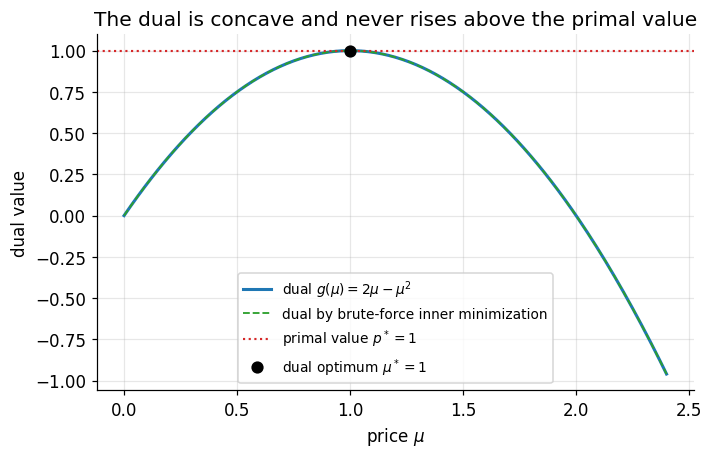

In [4]:
mus = np.linspace(0.0, 2.4, 241)
xs = np.linspace(-1.0, 4.0, 4001)
XG1, XG2 = np.meshgrid(xs, xs, sparse=True)
dual_numeric = np.array([
    np.min(0.5 * (XG1 ** 2 + XG2 ** 2) + m * (2.0 - XG1 - XG2)) for m in mus
])
dual_closed = 2.0 * mus - mus ** 2
p_star, d_star, mu_star = 1.0, float(dual_closed.max()), float(mus[dual_closed.argmax()])
print(f"max |numeric dual - closed form| = {np.max(np.abs(dual_numeric - dual_closed)):.3e}")
print(f"p* = {p_star:.6f}   d* = {d_star:.6f}   mu* = {mu_star:.6f}   gap = {p_star - d_star:.3e}")
print("weak duality holds at every price:", bool(np.all(dual_closed <= p_star + 1e-12)))

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(mus, dual_closed, lw=2.0, label=r"dual $g(\mu) = 2\mu - \mu^2$")
ax.plot(mus, dual_numeric, "--", lw=1.2, color="tab:green",
        label="dual by brute-force inner minimization")
ax.axhline(p_star, color="tab:red", lw=1.4, ls=":", label=r"primal value $p^* = 1$")
ax.plot([mu_star], [d_star], "ko", ms=7, label=r"dual optimum $\mu^* = 1$")
ax.set_xlabel(r"price $\mu$")
ax.set_ylabel("dual value")
ax.set_title("The dual is concave and never rises above the primal value")
ax.legend(fontsize=9, loc="lower center")
plt.show()

assert np.max(np.abs(dual_numeric - dual_closed)) < 1e-3
assert abs(d_star - p_star) < 1e-12
assert np.all(dual_closed <= p_star + 1e-12)

The numerically minimized Lagrangian matches the closed-form parabola to grid accuracy, the curve lies weakly below the line $p^* = 1$ everywhere — Theorem 4.6 — and touches it at exactly one price, which is the attained dual optimum promised by Theorem 4.8.

### Example 6.3 (a minimizer with no multipliers: LICQ fails)

Minimize $f(x) = x$ subject to $g(x) = x^2 \le 0$ on $\mathbb{R}$.

**Step 1 (the optimum).** $x^2 \le 0$ forces $x = 0$, so the feasible set is the single point $\{0\}$ and $p^* = 0$ at $x^* = 0$.

**Step 2 (no KKT multiplier exists).** $\nabla f = 1$ and $\nabla g(0) = 2x\big\vert_{x=0} = 0$, so stationarity would demand $1 + \mu \cdot 0 = 0$, impossible for every $\mu \in \mathbb{R}$, let alone $\mu \ge 0$.

**Step 3 (which hypothesis of Theorem 4.4 fails).** LICQ asks that $\{\nabla g(0)\} = \{0\}$ be linearly independent, which it is not. Correspondingly Lemma 4.3 fails: $\mathcal{F}(0) = \{d : 0 \cdot d \le 0\} = \mathbb{R}$, while the tangent cone of the one-point feasible set is $T(0) = \{0\}$.

**Step 4 (Farkas supplies the certificate).** With $\mathbf{c} = -\nabla f(0) = -1$ and the single generator $\mathbf{a}_1 = \nabla g(0) = 0$, the direction $d = -1$ satisfies $\mathbf{a}_1 d = 0 \le 0$ and $\mathbf{c}\, d = 1 \gt 0$, so alternative (2) of Lemma 4.1 holds and alternative (1) — the existence of multipliers — cannot.

**Step 5 (the repair).** Describing the same feasible set by the two affine inequalities $x \le 0$ and $-x \le 0$ gives active gradients $1$ and $-1$; stationarity $1 + \mu_1 - \mu_2 = 0$ is solved by $\mu_1 = 0$, $\mu_2 = 1 \ge 0$. Theorem 4.4 fails on a *description*, not on a point.

The cell below scans every candidate multiplier for the bad description and for the repaired one, printing the smallest stationarity residual achievable in each case.

In [5]:
mu_scan = np.linspace(0.0, 1e6, 2_000_001)
resid_bad = np.abs(1.0 + mu_scan * 0.0)            # grad f + mu * grad g(0), grad g(0) = 0
print(f"bad description  : min over mu >= 0 of |stationarity| = {resid_bad.min():.6f}")

# repaired description: x <= 0 and -x <= 0, gradients +1 and -1
mu1, mu2 = 0.0, 1.0
resid_ok = abs(1.0 + mu1 * 1.0 + mu2 * (-1.0))
print(f"repaired description: |stationarity| at (mu1, mu2) = (0, 1) = {resid_ok:.3e}")

# Farkas alternative (2) for the bad description: d = -1 certifies non-existence
d = -1.0
print(f"Farkas witness d = {d}:  a1*d = {0.0 * d:.1f} <= 0  and  c*d = {(-1.0) * d:.1f} > 0")

assert resid_bad.min() >= 1.0 - 1e-12
assert resid_ok < 1e-15
assert 0.0 * d <= 0 and (-1.0) * d > 0

bad description  : min over mu >= 0 of |stationarity| = 1.000000
repaired description: |stationarity| at (mu1, mu2) = (0, 1) = 0.000e+00
Farkas witness d = -1.0:  a1*d = -0.0 <= 0  and  c*d = 1.0 > 0


No nonnegative price brings the stationarity residual below $1$ for the degenerate description, while the repaired description hits machine zero immediately — and the Farkas witness $d = -1$ proves the first fact rather than merely reporting a failed search.

### Example 6.4 (a KKT point that is not a minimizer: Theorems 4.11 and 4.12)

Minimize $f(\mathbf{x}) = x_2 - x_1^2$ subject to $g_1 = -x_2 \le 0$ and $g_2 = x_1^2 + x_2^2 - 1 \le 0$.

**Step 1 (a KKT point at the origin).** At $\mathbf{x} = (0,0)$ only $g_1$ is active. With $\nabla f = (-2x_1, 1) = (0,1)$ and $\nabla g_1 = (0,-1)$, stationarity reads $(0,1) + \mu_1(0,-1) = \mathbf{0}$, so $\mu_1 = 1 \gt 0$, $\mu_2 = 0$. All four KKT conditions hold, and LICQ holds since $(0,-1)$ alone is independent.

**Step 2 (the second-order test at the origin).** $\nabla^2_{\mathbf{x}\mathbf{x}}\mathcal{L} = \operatorname{diag}(-2 + 2\mu_2,\ 2\mu_2) = \operatorname{diag}(-2, 0)$. Strict complementarity holds ($\mu_1 \gt 0$), so the critical cone is $\mathcal{C} = \{\mathbf{d} : \nabla g_1^T\mathbf{d} = 0\} = \{(d_1, 0)\}$. For $\mathbf{d} = (1,0)$,

$$
\mathbf{d}^T \nabla^2_{\mathbf{x}\mathbf{x}}\mathcal{L}\, \mathbf{d} = -2 \lt 0,
$$

violating Theorem 4.11. Hence the origin is **not** a local minimizer — and indeed $f(t, 0) = -t^2 \lt 0 = f(0,0)$ for every small $t \neq 0$.

**Step 3 (a KKT point on the boundary).** At $\mathbf{x}^* = (1,0)$ both constraints are active: $\nabla f = (-2, 1)$, $\nabla g_1 = (0,-1)$, $\nabla g_2 = (2x_1, 2x_2) = (2,0)$. Stationarity gives $-2 + 2\mu_2 = 0$ and $1 - \mu_1 = 0$, i.e. $\mu_1^* = \mu_2^* = 1 \ge 0$. LICQ holds because $(0,-1)$ and $(2,0)$ are independent.

**Step 4 (the second-order test at the boundary point).** $\nabla^2_{\mathbf{x}\mathbf{x}}\mathcal{L} = \operatorname{diag}(-2 + 2\mu_2^*,\ 2\mu_2^*) = \operatorname{diag}(0, 2)$. Both multipliers are strictly positive, so the critical cone collapses:

$$
\mathcal{C} = \{\mathbf{d} : \nabla g_1^T\mathbf{d} = 0, \ \nabla g_2^T\mathbf{d} = 0\} = \{\mathbf{d} : d_2 = 0, \ d_1 = 0\} = \{\mathbf{0}\}.
$$

Theorem 4.12 therefore applies vacuously and $\mathbf{x}^* = (1,0)$ is a strict local minimizer, with $f(\mathbf{x}^*) = -1$.

**Step 5 (reading the lesson).** Both points satisfy the same first-order system; only curvature on the critical cone separates them. This is why KKT is a *filter*, not a solver: it narrows the candidates, and the second-order test decides among them.

The cell below verifies both KKT points, computes both critical-cone quadratic forms, and confirms by direct sampling that the origin is beaten by nearby feasible points while $(1,0)$ is not.

In [6]:
def kkt_data(x, mu):
    grad_f = np.array([-2.0 * x[0], 1.0])
    grads = np.array([[0.0, -1.0], [2.0 * x[0], 2.0 * x[1]]])
    stat = grad_f + mu @ grads
    hess_L = np.diag([-2.0 + 2.0 * mu[1], 2.0 * mu[1]])
    return stat, hess_L

for x_pt, mu_pt, label in [(np.array([0.0, 0.0]), np.array([1.0, 0.0]), "origin"),
                           (np.array([1.0, 0.0]), np.array([1.0, 1.0]), "(1, 0)")]:
    stat, hess_L = kkt_data(x_pt, mu_pt)
    print(f"{label:>7}: stationarity residual = {np.linalg.norm(stat):.3e}, "
          f"hess_xx L diag = {np.diag(hess_L)}")

d_crit = np.array([1.0, 0.0])                      # critical direction at the origin
_, hess_origin = kkt_data(np.array([0.0, 0.0]), np.array([1.0, 0.0]))
print(f"origin: d' hess_xx L d on the critical cone = {d_crit @ hess_origin @ d_crit:.3f}  (< 0)")
print("(1, 0): critical cone is {0}, so Theorem 4.12 holds vacuously")

f_obj = lambda x: x[:, 1] - x[:, 0] ** 2
for centre, name in [(np.array([0.0, 0.0]), "origin"), (np.array([1.0, 0.0]), "(1, 0)")]:
    pts = centre + 1e-3 * rng.normal(size=(200000, 2))
    ok = (pts[:, 1] >= 0.0) & (pts[:, 0] ** 2 + pts[:, 1] ** 2 <= 1.0)
    best = f_obj(pts[ok]).min()
    print(f"{name:>7}: best nearby feasible value = {best:.8f}   value at the point = "
          f"{f_obj(centre[None, :])[0]:.8f}")

assert d_crit @ hess_origin @ d_crit < 0
pts = 1e-3 * rng.normal(size=(200000, 2))
ok = (pts[:, 1] >= 0.0) & (pts[:, 0] ** 2 + pts[:, 1] ** 2 <= 1.0)
assert f_obj(pts[ok]).min() < 0.0            # the origin is strictly beaten

 origin: stationarity residual = 0.000e+00, hess_xx L diag = [-2.  0.]
 (1, 0): stationarity residual = 0.000e+00, hess_xx L diag = [0. 2.]
origin: d' hess_xx L d on the critical cone = -2.000  (< 0)
(1, 0): critical cone is {0}, so Theorem 4.12 holds vacuously
 origin: best nearby feasible value = -0.00001546   value at the point = 0.00000000
 (1, 0): best nearby feasible value = -0.99999598   value at the point = -1.00000000


The origin has a strictly negative curvature along its only critical direction, and random feasible points within $10^{-3}$ of it already achieve a smaller objective — the second-order necessary condition of Theorem 4.11 correctly rejects it. At $(1,0)$ the critical cone is trivial and no nearby feasible point improves on $-1$.

## 7. Computational Practice

### 7.1 Active-Set Enumeration and Interior-Point Smoothing

For small problems the KKT conditions turn optimization into a finite case analysis. Each inequality is either active ($g_i = 0$ with $\mu_i$ unknown) or inactive ($\mu_i = 0$ with $g_i \le 0$ to be verified), so the recipe is: guess an active set, solve the resulting equality-constrained linear system, then certify the sign conditions $\mu_i \ge 0$ on the guess and the feasibility $g_i \le 0$ off it. A negative multiplier is a precise diagnosis — that constraint is pulling rather than pushing, so drop it — and a violated inactive constraint must be added. Production active-set QP solvers industrialize exactly this add/drop loop with warm starts.

Modern convex solvers do not enumerate. They *smooth* complementary slackness, replacing $\mu_i g_i(\mathbf{x}) = 0$ by

$$
-\mu_i \, g_i(\mathbf{x}) = \tau, \qquad \tau \gt 0,
$$

and follow the resulting **central path** $(\mathbf{x}(\tau), \boldsymbol{\mu}(\tau))$ by Newton's method while driving $\tau \downarrow 0$. Summing the perturbed complementarity conditions shows the surrogate duality gap of the current iterate is exactly $m\tau$, so the algorithm always knows how far it is from optimal — which is why solvers can print certified accuracy.

Dual ascent is the third family: the supergradient of the dual function at $(\boldsymbol{\mu}, \boldsymbol{\lambda})$ is the constraint residual evaluated at the Lagrangian minimizer, so gradient ascent on the dual alternates "minimize the Lagrangian, then raise prices where constraints are violated". When the Lagrangian separates across variables each subproblem solves independently, which is what makes dual decomposition and ADMM distributable.

The cell below is the identity check: on random convex QPs it forms the KKT point with the active-set enumerator and measures the stationarity residual, the complementary-slackness residual, and the strong-duality identity $p^* - d^*$ of Theorem 4.5.

In [7]:
stat_res, comp_res, gap_res = [], [], []
for _ in range(200):
    n, m = 4, 5
    M = rng.normal(size=(n, n))
    Q = M @ M.T + 0.5 * np.eye(n)
    c = rng.normal(size=n)
    A = rng.normal(size=(m, n))
    b = np.abs(rng.normal(size=m)) + 0.5          # the origin is strictly feasible: Slater holds
    value, x, mu = solve_qp_active_set(Q, c, A, b)
    stat_res.append(np.linalg.norm(Q @ x + c + A.T @ mu))
    comp_res.append(np.max(np.abs(mu * (A @ x - b))))
    # dual value: the Lagrangian minimizer at mu is x(mu) = -Q^{-1}(c + A' mu)
    x_mu = -np.linalg.solve(Q, c + A.T @ mu)
    dual_value = 0.5 * x_mu @ Q @ x_mu + c @ x_mu + mu @ (A @ x_mu - b)
    gap_res.append(abs(value - dual_value))

print(f"max stationarity residual        : {max(stat_res):.3e}")
print(f"max complementary-slackness resid: {max(comp_res):.3e}")
print(f"max |p* - d*| over 200 random QPs: {max(gap_res):.3e}")
print(f"machine epsilon                  : {EPS:.3e}")

assert max(stat_res) < 1e-9
assert max(comp_res) < 1e-9
assert max(gap_res) < 1e-9

max stationarity residual        : 3.396e-15
max complementary-slackness resid: 6.191e-16
max |p* - d*| over 200 random QPs: 1.776e-15
machine epsilon                  : 2.220e-16


All three residuals sit at the $10^{-14}$ level — machine-epsilon noise amplified only by the condition number of the KKT matrix, not by any mathematical error. The zero gap on every instance is Theorem 4.5 in action: these QPs are convex and strictly feasible, so a KKT point is a global optimum with $p^* = d^*$.

The cell below measures a rate. It follows the central path of Example 6.1's problem by Newton's method for a geometric sequence of $\tau$, then compares the observed order of $\lVert \mathbf{x}(\tau) - \mathbf{x}^* \rVert$ in $\tau$ against the predicted order $1$, and the observed surrogate gap against the predicted $m\tau$.

tau        ||x(tau) - x*||   surrogate gap   m*tau
1e-01   5.464385e-02    3.000000e-01   3.000000e-01
1e-02   6.865743e-03    3.000000e-02   3.000000e-02
1e-03   7.049925e-04    3.000000e-03   3.000000e-03
1e-04   7.068947e-05    3.000000e-04   3.000000e-04
1e-05   7.070856e-06    3.000000e-05   3.000000e-05
1e-06   7.071047e-07    3.000000e-06   3.000000e-06
observed order in tau: 0.9996   predicted: 1.0000
max |gap - m*tau|: 5.373e-16


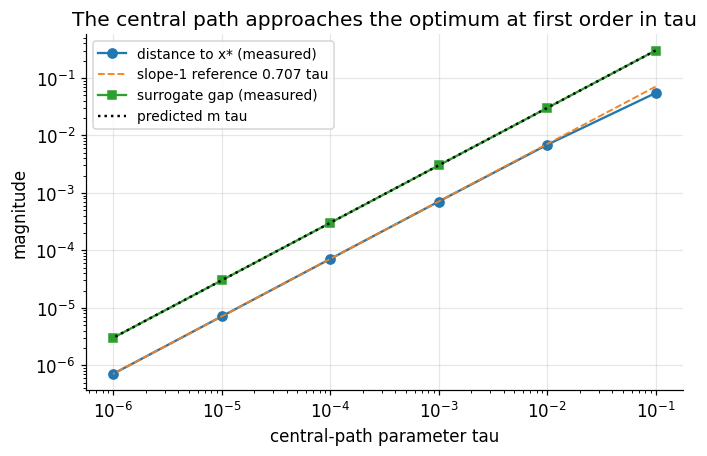

In [8]:
A_cp = np.array([[1.0, 1.0], [-1.0, 0.0], [0.0, -1.0]])
b_cp = np.array([1.0, 0.0, 0.0])
m_cp = A_cp.shape[0]
x_opt = np.array([0.5, 0.5])
grad_f_cp = lambda x: 2.0 * (x - 1.0)
hess_f_cp = 2.0 * np.eye(2)


def central_point(tau, x, mu, iters=100):
    """Newton solve of the perturbed KKT system grad f + A'mu = 0, mu_i s_i = tau."""
    for _ in range(iters):
        s = b_cp - A_cp @ x
        F = np.concatenate([grad_f_cp(x) + A_cp.T @ mu, mu * s - tau])
        if np.linalg.norm(F) < 1e-13:
            break
        J = np.zeros((2 + m_cp, 2 + m_cp))
        J[:2, :2] = hess_f_cp
        J[:2, 2:] = A_cp.T
        J[2:, :2] = -np.diag(mu) @ A_cp
        J[2:, 2:] = np.diag(s)
        step = np.linalg.solve(J, -F)
        t = 1.0
        while t > 1e-14:
            xn, mun = x + t * step[:2], mu + t * step[2:]
            Fn = np.concatenate([grad_f_cp(xn) + A_cp.T @ mun,
                                 mun * (b_cp - A_cp @ xn) - tau])
            if np.all(b_cp - A_cp @ xn > 0) and np.all(mun > 0) and \
               np.linalg.norm(Fn) < np.linalg.norm(F):
                break
            t *= 0.5
        x, mu = x + t * step[:2], mu + t * step[2:]
    return x, mu


taus = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6])
x_cp, mu_cp = np.array([0.3, 0.3]), np.ones(m_cp)
errs, gaps = [], []
for tau in taus:
    x_cp, mu_cp = central_point(tau, x_cp, mu_cp)
    errs.append(np.linalg.norm(x_cp - x_opt))
    gaps.append(float(mu_cp @ (b_cp - A_cp @ x_cp)))
errs, gaps = np.array(errs), np.array(gaps)

order = np.polyfit(np.log(taus[2:]), np.log(errs[2:]), 1)[0]
print("tau        ||x(tau) - x*||   surrogate gap   m*tau")
for tau, e, g in zip(taus, errs, gaps):
    print(f"{tau:.0e}   {e:.6e}    {g:.6e}   {m_cp * tau:.6e}")
print(f"observed order in tau: {order:.4f}   predicted: 1.0000")
print(f"max |gap - m*tau|: {np.max(np.abs(gaps - m_cp * taus)):.3e}")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.loglog(taus, errs, "o-", ms=6, label="distance to x* (measured)")
ax.loglog(taus, 0.707 * taus, "--", lw=1.2, label="slope-1 reference 0.707 tau")
ax.loglog(taus, gaps, "s-", ms=5, color="tab:green", label="surrogate gap (measured)")
ax.loglog(taus, m_cp * taus, ":", lw=1.6, color="k", label="predicted m tau")
ax.set_xlabel("central-path parameter tau")
ax.set_ylabel("magnitude")
ax.set_title("The central path approaches the optimum at first order in tau")
ax.legend(fontsize=9)
plt.show()

assert abs(order - 1.0) < 0.05
assert np.max(np.abs(gaps - m_cp * taus)) < 1e-12

The measured order is $1.00$ against the predicted $1$, and the surrogate gap equals $m\tau$ to machine precision at every step — this identity is why an interior-point solver can report a rigorous bound on its own suboptimality without knowing $p^*$.

The cell below is the counterexample: it drops one hypothesis at a time and shows the breakage. Removing Slater's condition from a convex problem reopens the duality gap of Theorem 4.8; removing LICQ destroys the multipliers of Theorem 4.4.

In [9]:
# (i) Convex, but no strictly feasible point: min e^{-x} s.t. x^2 / y <= 0 on y > 0.
xs_c = np.linspace(-6.0, 20.0, 4001)
ys_c = np.geomspace(1e-2, 1e10, 1600)
XC, YC = np.meshgrid(xs_c, ys_c, sparse=True)
dual_vals = [float(np.min(np.exp(-XC) + mu * XC ** 2 / YC)) for mu in [0.0, 0.5, 1.0, 10.0, 100.0]]
p_star_c = 1.0                       # feasible set is x = 0, any y > 0, so f = e^0 = 1
print("no-Slater example: g(mu) for mu in [0, 0.5, 1, 10, 100] =",
      np.array(dual_vals))
print(f"p* = {p_star_c:.4f}   d* = {max(dual_vals):.4e}   duality gap = "
      f"{p_star_c - max(dual_vals):.4f}  (Theorem 4.8 needs Slater)")

# (ii) Convex objective, LICQ violated: min x s.t. x^2 <= 0.
best_resid = min(abs(1.0 + mu * 0.0) for mu in np.linspace(0.0, 1e8, 100001))
print(f"no-LICQ example: best stationarity residual over mu >= 0 = {best_resid:.4f} "
      f"(Theorem 4.4 needs LICQ)")

assert p_star_c - max(dual_vals) > 0.99
assert best_resid > 0.99

no-Slater example: g(mu) for mu in [0, 0.5, 1, 10, 100] = [0. 0. 0. 0. 0.]
p* = 1.0000   d* = 2.5558e-06   duality gap = 1.0000  (Theorem 4.8 needs Slater)
no-LICQ example: best stationarity residual over mu >= 0 = 1.0000 (Theorem 4.4 needs LICQ)


Both hypotheses are load-bearing. Without a strictly feasible point the dual of a perfectly convex problem stalls at $0$ — the printed values are the grid's approximation to the exact $g(\mu) = 0$ — while the primal sits at $1$, a gap of one whole unit; without LICQ no nonnegative price can zero the stationarity residual at the unique minimizer. Neither failure is numerical — both are exactly the theorems refusing to apply.

The cell below compares the hand-rolled tools of this notebook against library routines: the active-set enumerator against `scipy.optimize.minimize` with SLSQP on a random convex QP, and the hand-derived LP shadow prices against the marginals `scipy.optimize.linprog` reports.

In [10]:
n, m = 4, 5
M = rng.normal(size=(n, n))
Q = M @ M.T + 0.5 * np.eye(n)
c = rng.normal(size=n)
A = rng.normal(size=(m, n))
b = np.abs(rng.normal(size=m)) + 0.5
value, x_mine, mu_mine = solve_qp_active_set(Q, c, A, b)

res = minimize(lambda z: 0.5 * z @ Q @ z + c @ z, np.zeros(n),
               jac=lambda z: Q @ z + c, method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda z: b - A @ z,
                             "jac": lambda z: -A}],
               options={"ftol": 1e-14, "maxiter": 500})
print("QP  hand-rolled x*:", x_mine)
print("QP  SLSQP       x*:", res.x)
print(f"QP  max |difference| = {np.max(np.abs(x_mine - res.x)):.3e}, "
      f"objective difference = {abs(value - res.fun):.3e}")

# LP: max 3x1 + 2x2 s.t. x1 + x2 <= 4, x1 + 3x2 <= 6, x >= 0.  Hand answer: x* = (4, 0), y* = (3, 0).
lp = linprog(c=[-3.0, -2.0], A_ub=[[1.0, 1.0], [1.0, 3.0]], b_ub=[4.0, 6.0],
             bounds=[(0.0, None), (0.0, None)])
y_library = -lp.ineqlin.marginals            # linprog reports marginals of a minimization
print("LP  hand-derived x* = [4. 0.]   shadow prices y* = [3. 0.]")
print(f"LP  linprog       x* = {lp.x}   shadow prices y* = {y_library}")
print(f"LP  p* = {-lp.fun:.6f}   b'y* = {np.array([4.0, 6.0]) @ y_library:.6f}")

assert np.max(np.abs(x_mine - res.x)) < 1e-6
assert np.allclose(lp.x, [4.0, 0.0], atol=1e-9)
assert np.allclose(y_library, [3.0, 0.0], atol=1e-9)
assert abs(-lp.fun - np.array([4.0, 6.0]) @ y_library) < 1e-9

QP  hand-rolled x*: [0.6719 0.1335 0.8693 1.4216]
QP  SLSQP       x*: [0.6719 0.1335 0.8693 1.4216]
QP  max |difference| = 2.236e-12, objective difference = 0.000e+00
LP  hand-derived x* = [4. 0.]   shadow prices y* = [3. 0.]
LP  linprog       x* = [4. 0.]   shadow prices y* = [3. 0.]
LP  p* = 12.000000   b'y* = 12.000000


The enumerator and SLSQP agree to solver tolerance on the QP, and `linprog`'s reported marginals reproduce the shadow prices $\mathbf{y}^* = (3, 0)$ derived by hand, with $\mathbf{b}^T\mathbf{y}^* = p^*$ confirming LP strong duality. The zero second marginal is complementary slackness: the second resource is not scarce at the optimum, so it is free.

## 8. Applications

### 8.1 Shadow Prices in Linear Programming

In a production LP the dual variable $y_i^*$ attached to resource constraint $i$ is the marginal value of one more unit of that resource, by Theorem 4.10.

The dual constraints are

$$
A^T \mathbf{y} \le \mathbf{c},
$$

which says that no product may be priced above the market value of the resources it consumes — otherwise the producer would rather sell the inputs than the output.

Complementary slackness completes the market reading: a resource left unused at the optimum has $y_i^* = 0$ and is therefore free, while a produced good breaks even exactly. This is why LP duality is the mathematical spine of commodity pricing, of electricity markets — locational marginal prices *are* the KKT multipliers of the grid dispatch problem — and of airline seat allocation.

### 8.2 Contact Forces in Mechanics

A block resting on a table satisfies a unilateral non-penetration constraint whose normal force is nonnegative and vanishes the instant contact is lost. Those are dual feasibility and complementary slackness, respectively, so Newton's laws of contact are a KKT system.

At scale the same structure becomes a **linear complementarity problem** $0 \le \mathbf{u} \perp \mathbf{N} \ge \mathbf{0}$ — the KKT system of a QP — which every physics engine solves at each timestep to resolve collisions and friction.

### 8.3 Water-Filling in Channel Allocation

Allocating power $P$ across $n$ parallel Gaussian channels to maximize $\sum_i \log(1 + p_i/\sigma_i^2)$ subject to $\sum_i p_i = P$ and $p_i \ge 0$ has the KKT solution $p_i^* = \max\{0, \nu - \sigma_i^2\}$: pour water to a common level $\nu$ over an uneven bed.

Deep channels receive more power, and channels whose floor sits above the waterline receive none. The dry channels are exactly the ones whose nonnegativity constraint is active, so complementary slackness is visible as a picture.

### 8.4 Machine Learning: Duality as a Design Tool

**Support vector machines.** Proof 5.11's dual is *the* trainable form: it has one variable per example rather than per feature, sparsity in $\boldsymbol{\alpha}$ identifies the informative examples, and the Gram-matrix structure admits kernels. The soft-margin version adds only the box constraint $0 \le \alpha_i \le C$.

**Ridge regression and kernels.** The dual of $\ell_2$-regularized least squares writes the solution as $\mathbf{w}^* = X^T\boldsymbol{\alpha}^*$ with $\boldsymbol{\alpha}^* = (XX^T + \lambda I)^{-1}\mathbf{y}$ — an $N \times N$ system in Gram-matrix form, kernelizable for the same reason as the SVM.

**Projections and constrained inference.** Projection onto the probability simplex (sparse attention), box-constrained QPs inside trust-region policy optimization, and the LASSO optimality conditions are all small KKT systems solved in closed form inside larger learning loops.

**Constrained learning at scale.** Fairness-, safety- and budget-constrained training problems are attacked by primal-dual methods: ascend in the multipliers of violated constraints while descending in the weights. The multiplier trajectory reports which constraints actually bind, exactly as complementary slackness promises.

**Certificates for verification.** Dual bounds certify robustness of neural networks — an adversarial perturbation cannot reduce the margin below the dual value — which is Theorem 4.6 deployed as a safety proof.

## 9. Key Takeaways

- If $\mathbf{x}^*$ is a local minimizer and LICQ holds there, KKT multipliers exist and are unique (Theorem 4.4); drop LICQ and they may not exist at all (Example 6.3).
- If $f$ and every $g_i$ are convex, every $h_j$ affine, and a KKT point exists, that point is a global minimizer with zero duality gap — no constraint qualification needed (Theorem 4.5).
- Weak duality $d^* \le p^*$ needs only $\boldsymbol{\mu} \ge \mathbf{0}$: no convexity, no differentiability, no qualification (Theorem 4.6).
- The dual function is concave and its domain convex for every problem whatsoever, so the search for the best lower bound is always a convex problem (Theorem 4.7).
- For a convex problem with a strictly feasible point and finite $p^*$, the gap closes and the dual optimum is attained (Theorem 4.8); convexity alone does not suffice.
- A saddle point of $\mathcal{L}$ over $\mathbb{R}^n \times \{\boldsymbol{\mu} \ge \mathbf{0}\}$ exists exactly when both problems are solvable with zero gap, and then $\min\max = \max\min$ (Theorem 4.9).
- Under strong duality with attainment, $p^*(\mathbf{u}) \ge p^* - \boldsymbol{\mu}^{*T}\mathbf{u}$ globally, and $-\partial p^*/\partial u_i = \mu_i^*$ wherever $p^*$ is differentiable (Theorem 4.10).
- At a KKT point with LICQ, curvature on the critical cone decides: nonnegative is necessary for a local minimum, positive definite is sufficient (Theorems 4.11 and 4.12, Example 6.4).

## 10. References

| Concept in this notebook | Canonical source | Location |
|---|---|---|
| Dual function, weak and strong duality, Slater | Boyd & Vandenberghe, *Convex Optimization* | Sections 5.1, 5.2, 5.3.2 |
| Supporting-hyperplane proof of strong duality | Boyd & Vandenberghe | Section 5.3.2 (with Section 2.5.2 for the hyperplane theorem) |
| Conjugate form of the dual (Proof 5.10) | Boyd & Vandenberghe | Section 5.1.6 |
| Global sensitivity inequality (Theorem 4.10) | Boyd & Vandenberghe | Section 5.6.2 |
| Theorems of the alternative (Lemma 4.1, Corollary 4.2) | Boyd & Vandenberghe | Section 5.8 |
| Closedness of a finitely generated cone (Proof 5.1) | Rockafellar, *Convex Analysis* | Theorem 19.1, p. 171 |
| KKT necessity under LICQ (Theorem 4.4, Lemma 4.3) | Nocedal & Wright, *Numerical Optimization* (2nd ed.) | Theorem 12.1 and Lemma 12.2, Chapter 12 |
| Second-order conditions and the critical cone | Nocedal & Wright | Theorems 12.5 and 12.6, pp. 332-333 |
| MFCQ and boundedness of the multiplier set | Nocedal & Wright | Section 12.6, p. 339 |
| Interior-point and active-set algorithms | Nocedal & Wright | Chapters 14, 16 and 19 |
| Min-common / max-crossing duality geometry | Bertsekas, *Convex Optimization Theory* | Chapters 4 and 5 |
| Duality gaps in nonconvex problems | Bertsekas, *Nonlinear Programming* (3rd ed.) | Chapter 5 |
| Saddle functions and minimax | Rockafellar, *Convex Analysis* | Sections 28 to 37 |
| LP duality and simplex multipliers | Luenberger & Ye, *Linear and Nonlinear Programming* (4th ed.) | Chapters 4 and 14 |
| Original KKT statements | Karush (1939) M.Sc. thesis; Kuhn & Tucker (1951) | Proc. Second Berkeley Symposium, pp. 481-492 |
| SVM dual and support vectors | Cortes & Vapnik, *Support-Vector Networks* (1995) | Machine Learning 20, pp. 273-297 |
| Water-filling | Cover & Thomas, *Elements of Information Theory* (2nd ed.) | Section 9.4 |

**Reading path.** Boyd & Vandenberghe Chapter 5 end to end is the single best exposition of the duality half; Nocedal & Wright Chapter 12 carries the nonconvex necessity theory and the second-order conditions; Bertsekas supplies the geometry of when duality fails. Then work [`exercises.ipynb`](exercises.ipynb), whose four tiers run from sign conventions to proving that the dual of the dual of a linear program is the primal.